# 05 · Análises e gráficos executivos
**Tech Challenge Fase 3 · State of Data Brasil (Data Hackers/Bain)**

| Item | Descrição |
|---|---|
| **Objetivo** | Gerar os 15 gráficos do material executivo a partir da camada Gold (agregados pequenos → pandas/matplotlib, conforme 14.6). |
| **Origem** | `../../datalake/gold/csv/<tabela>.csv` |
| **Destino** | `../../consumption/charts/*.png` (inseridos no material executivo e no relatório — R8/R10) |
| **Regras de DataViz** | Sem pizza/rosca acima de 3 categorias; todo gráfico com título, fonte, edição e `n` (regras 13.11 e 14.5). |

| Gráfico | Pergunta de negócio |
|---|---|
| G01 | Contexto/volumetria |
| G02–G03 | 1. Estrutura do mercado |
| G04–G05 | 2. Perfis valorizados |
| G06–G07 | 3. Diversidade de gênero |
| G08–G10 | 4. Tecnologias |
| G11–G12 | 5. Adoção de IA |
| G13–G14 | 6. Regiões e modelos de trabalho |
| G15 | 7. Oportunidades e desafios (EVP) |


## Padrão visual aplicado (docs/visual_standard.md)

Este notebook é a **fonte única** dos 15 PNGs entregues. As regras abaixo são implementadas nos
helpers da próxima célula, de modo que qualquer reexecução reproduz exatamente os arquivos do
material executivo e do relatório técnico:

| Regra | Implementação |
|---|---|
| Paleta institucional | `#1F3864` (série principal) · `#2E5395` (segunda) · `#7BA7D7` (terceira/edição mais antiga) · `#E8710A` (destaque) · `#8C8C8C` (contexto histórico) |
| Sem juízo de valor | vermelho/verde não são usados em categorias neutras |
| Formato | 10 × 5,2 pol a 200 dpi, sem molduras superior/direita |
| Grid | apenas no eixo de valor, alpha 0,25, atrás das barras |
| Margem | 20–30% reservados no eixo de valor (rótulos nunca cortados) |
| Números | PT-BR — vírgula decimal e ponto de milhar (`R$ 18.001` · `24,0%`) |
| Rodapé | fonte, edições e `n` amostral em faixa fixa, sem colidir com o eixo |


In [1]:
%matplotlib inline
# -*- coding: utf-8 -*-
"""Análises e gráficos | consumo da camada Gold (agregados pequenos -> pandas/matplotlib).

Padrão visual: docs/visual_standard.md — paleta institucional, PT-BR, rodapé com fonte/edição/n.
"""
import os
import textwrap
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

GOLD = "../../datalake/gold/csv"
OUT = "../../consumption/charts"
os.makedirs(OUT, exist_ok=True)

# ---- Paleta institucional (docs/visual_standard.md) ----------------------
AZUL, AZUL_MED, AZUL_CLARO = "#1F3864", "#2E5395", "#7BA7D7"
LARANJA, CINZA, CINZA_TXT = "#E8710A", "#8C8C8C", "#666666"
SERIE_ANOS = [AZUL_CLARO, AZUL_MED, AZUL]        # progressão temporal: claro -> institucional
ANOS_NUCLEO = [2023, 2024, 2025]
ROTULO_ANO = {2019: "2019", 2021: "2021", 2022: "2022",
              2023: "2023", 2024: "2024", 2025: "2025/26"}

mpl.rcParams.update({
    "figure.figsize": (10, 5.2), "figure.dpi": 200,
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.edgecolor": "#BFBFBF", "axes.linewidth": 0.8,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "legend.fontsize": 10.5, "legend.frameon": False,
})

# ---- Formatação PT-BR ----------------------------------------------------
def mil(v, casas=0):
    """1234.5 -> '1.234' (ponto de milhar, vírgula decimal)."""
    return f"{v:,.{casas}f}".replace(",", "@").replace(".", ",").replace("@", ".")

def pct(v, casas=1):
    return f"{mil(v, casas)}%"

FMT_MIL = FuncFormatter(lambda v, _: mil(v))
FMT_PCT = FuncFormatter(lambda v, _: mil(v))

def ler(nome):
    return pd.read_csv(f"{GOLD}/{nome}.csv")

# ---- Estrutura padrão do gráfico ----------------------------------------
def nova_fig(largura=10, altura=5.2, ncols=1):
    fig, ax = plt.subplots(1, ncols, figsize=(largura, altura))
    return fig, ax

def eixo(ax, valor="y", grid=True):
    """Remove molduras e aplica grid apenas no eixo de valor, atrás dos dados."""
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    if grid:
        ax.grid(axis=valor, alpha=0.25, zorder=0)
        ax.set_axisbelow(True)

def _fonte(anos, n, nota=""):
    """Faixa fixa: fonte, edições e n amostral (regra 13.11).
    `n` aceita um número (formatado em PT-BR) ou uma string já pronta — usada quando o n
    varia por edição de forma relevante para a leitura (ex.: G12, onde a base cai de
    3.772 para 2.106 entre 2023 e 2025/26 e um único número esconderia essa queda)."""
    anos = list(anos)
    if len(anos) == 1:
        ed = "Edição " + ROTULO_ANO[anos[0]]
    elif len(anos) > 3:
        ed = f"Edições {ROTULO_ANO[anos[0]]} a {ROTULO_ANO[anos[-1]]}"
    else:
        ed = "Edições " + ", ".join(ROTULO_ANO[a] for a in anos)
    n_txt = n if isinstance(n, str) else mil(n)
    txt = f"Fonte: State of Data Brasil — Data Hackers/Bain | {ed} | n = {n_txt}"
    return txt + (f" · {nota}" if nota else "")

def salvar(fig, nome, anos, n, nota="", rect=(0, 0, 1, 1)):
    """Fecha o gráfico no padrão: 10 x 5,2 pol a 200 dpi, rodapé em faixa reservada."""
    txt = _fonte(anos, n, nota)
    linhas = textwrap.wrap(txt, 148) or [txt]
    reserva = 0.055 + 0.030 * (len(linhas) - 1)          # faixa do rodapé
    fig.tight_layout(rect=[rect[0], rect[1] + reserva, rect[2], rect[3]])
    fig.text(0.012, 0.014, "\n".join(linhas), fontsize=8.5, color=CINZA_TXT,
             va="bottom", linespacing=1.6)
    fig.savefig(f"{OUT}/{nome}.png", dpi=200, facecolor="white")   # tamanho fixo, sem bbox tight
    plt.show()
    print("[grafico]", nome)

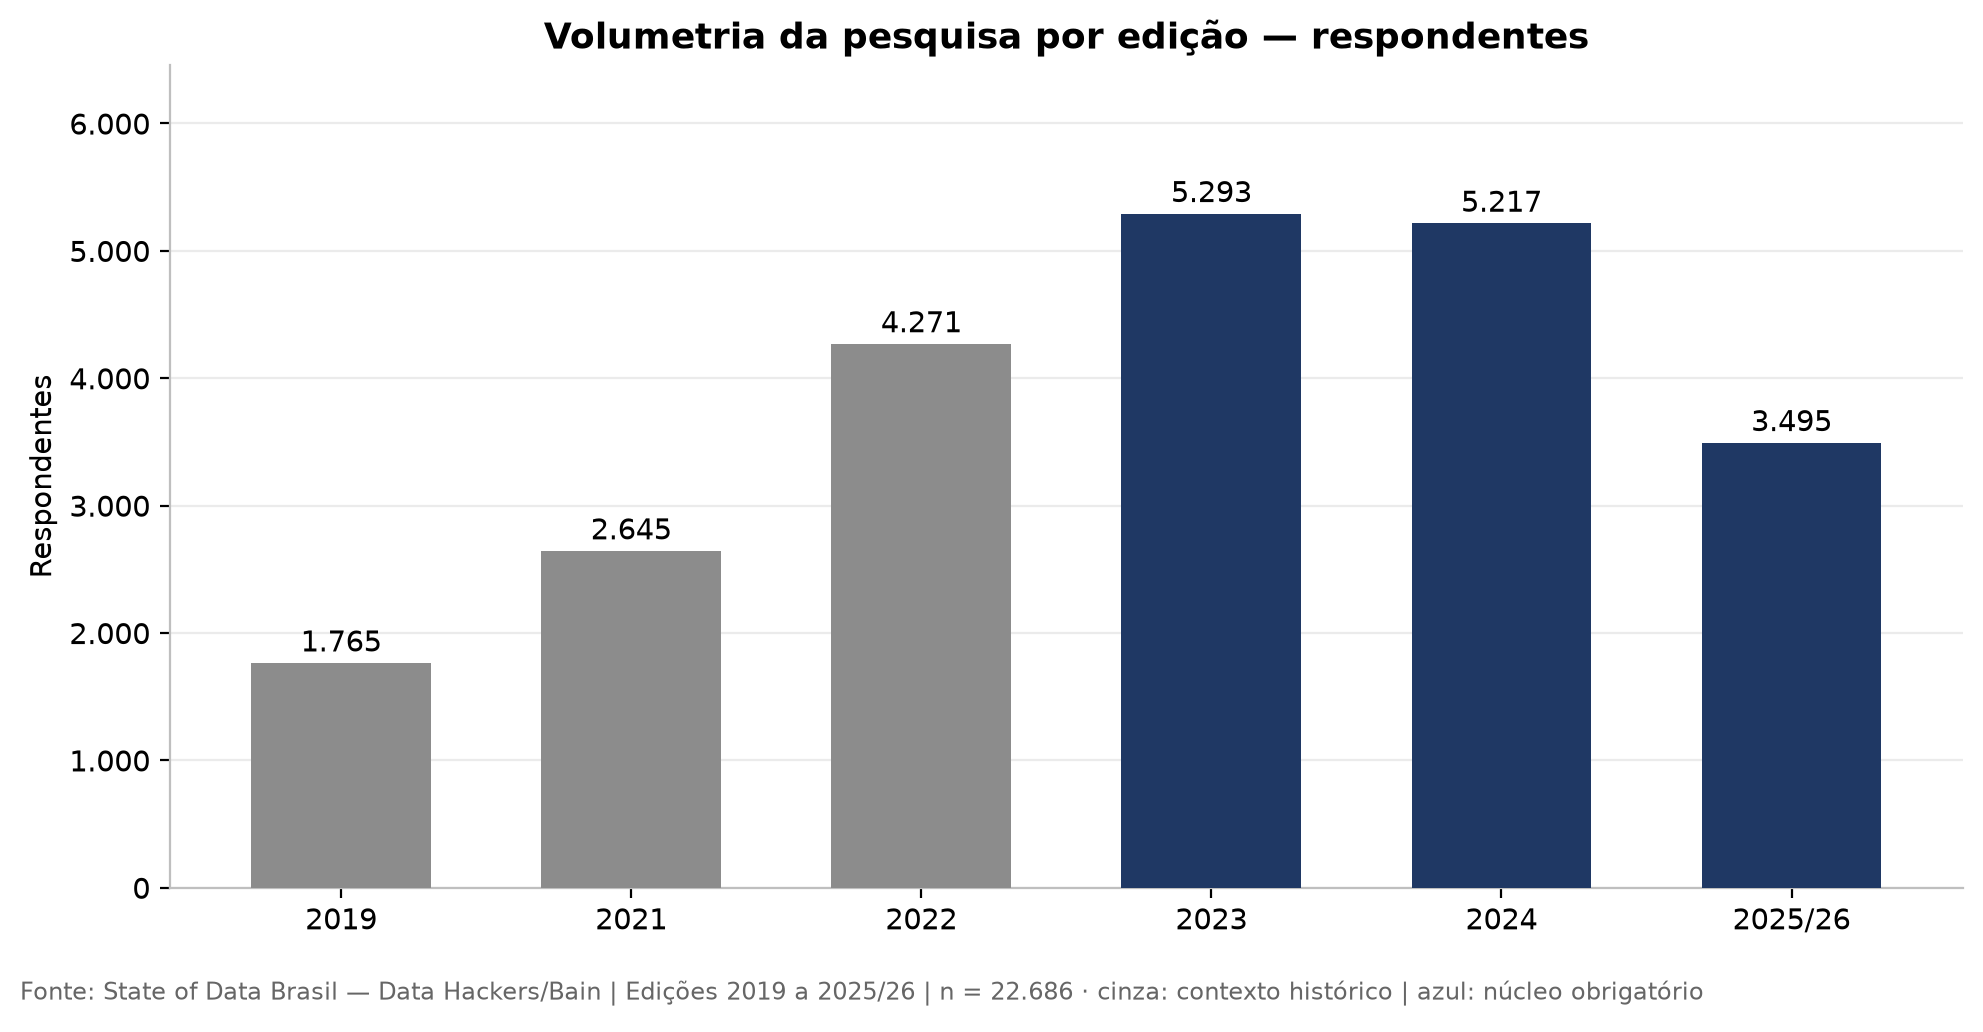

[grafico] G01_respondents_by_edition


In [2]:
# G01 — Respondentes por edição (contexto histórico x núcleo obrigatório) ---
d = ler("gold_respondents").sort_values("ano")
cores = [CINZA if a < 2023 else AZUL for a in d.ano]

fig, ax = nova_fig()
ax.bar([ROTULO_ANO[a] for a in d.ano], d.n, color=cores, width=0.62, zorder=3)
for x, v in enumerate(d.n):
    ax.text(x, v + 90, mil(v), ha="center", fontsize=10.5)
ax.set_title("Volumetria da pesquisa por edição — respondentes")
ax.set_ylabel("Respondentes")
ax.set_ylim(0, d.n.max() * 1.22)
ax.yaxis.set_major_formatter(FMT_MIL)
eixo(ax)
salvar(fig, "G01_respondents_by_edition", d.ano.tolist(), d.n.sum(), "cinza: contexto histórico | azul: núcleo obrigatório")

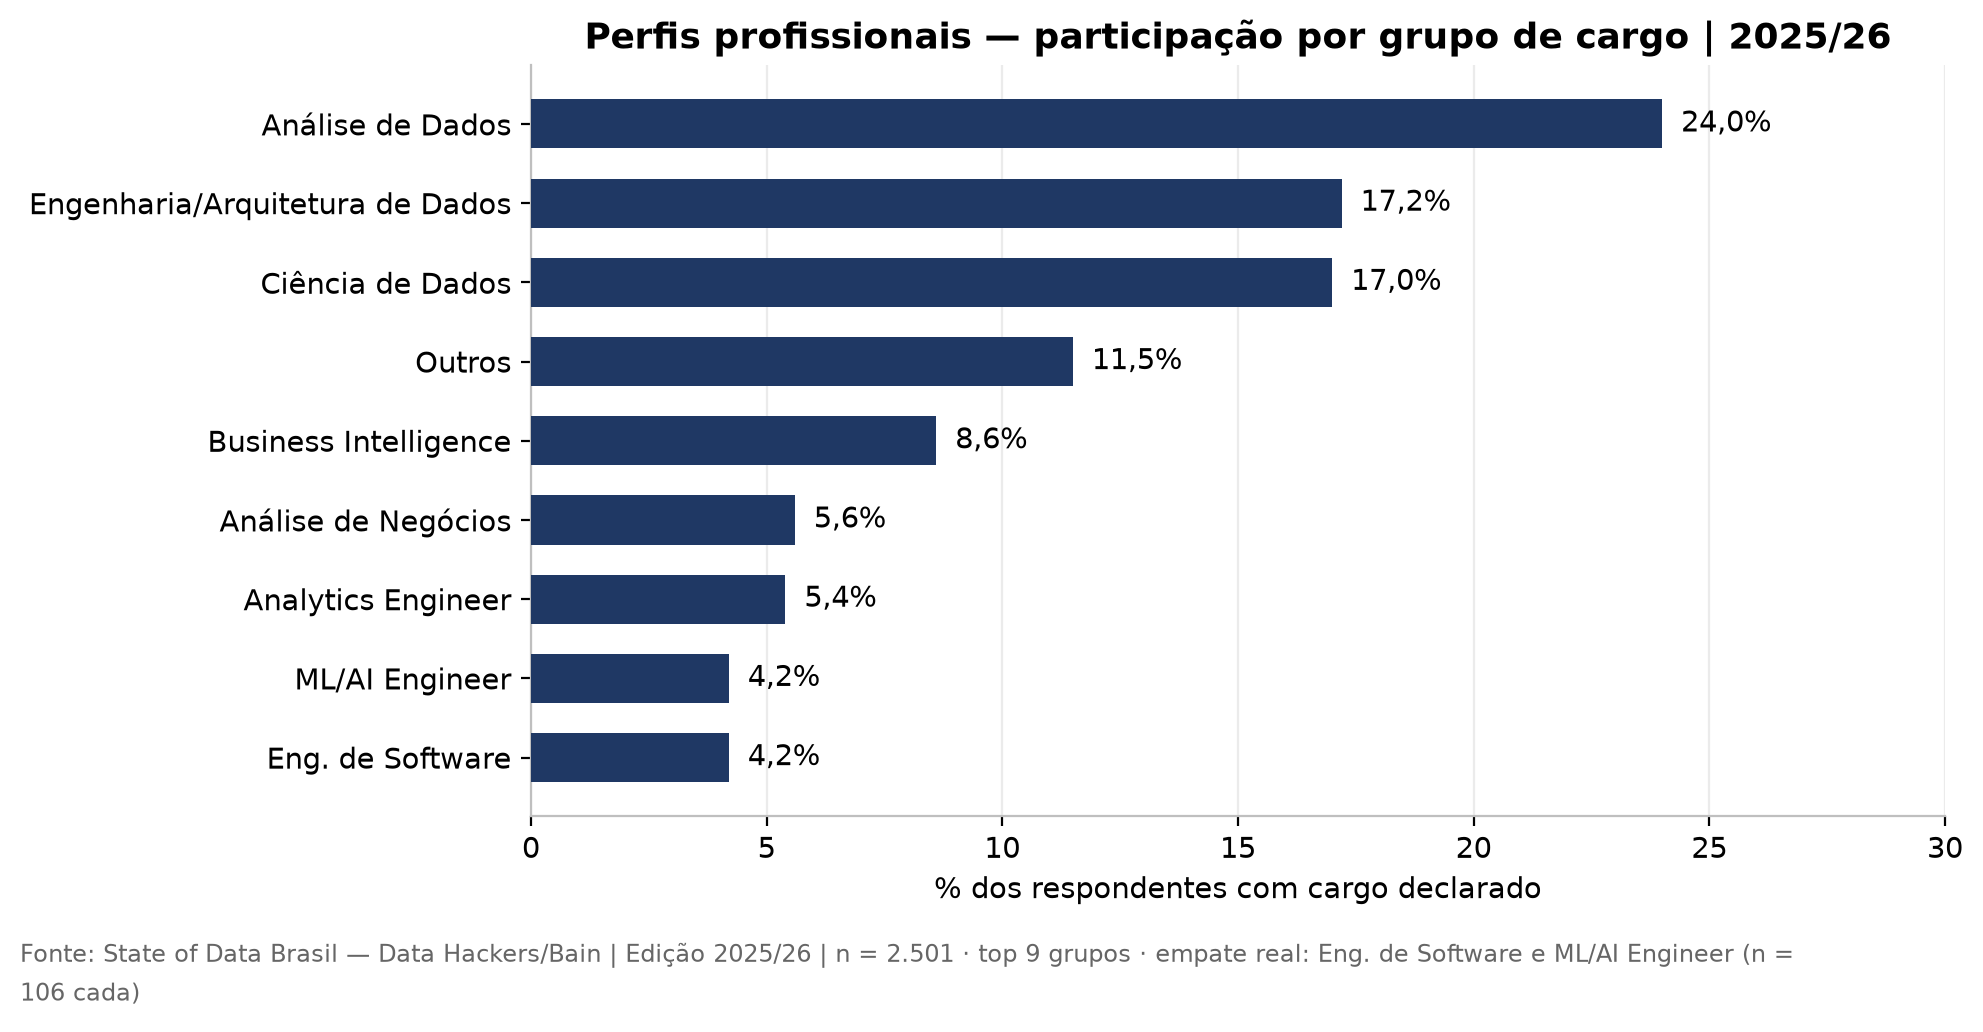

[grafico] G02_roles_2025


In [3]:
# G02 — Perfis profissionais: participação por grupo de cargo (2025/26) -----
d = ler("gold_roles"); d25 = d[d.ano == 2025]
top = d25.nlargest(9, "n").sort_values("n")

fig, ax = nova_fig()
ax.barh(top.cargo_grupo, top.pct, color=AZUL, height=0.62, zorder=3)
for y, v in enumerate(top.pct):
    ax.text(v + 0.4, y, pct(v), va="center", fontsize=10.5)
ax.set_title("Perfis profissionais — participação por grupo de cargo | 2025/26")
ax.set_xlabel("% dos respondentes com cargo declarado")
ax.set_xlim(0, top.pct.max() * 1.25)
eixo(ax, valor="x")
salvar(fig, "G02_roles_2025", [2025], d25.n.sum(),
       "top 9 grupos · empate real: Eng. de Software e ML/AI Engineer (n = 106 cada)")

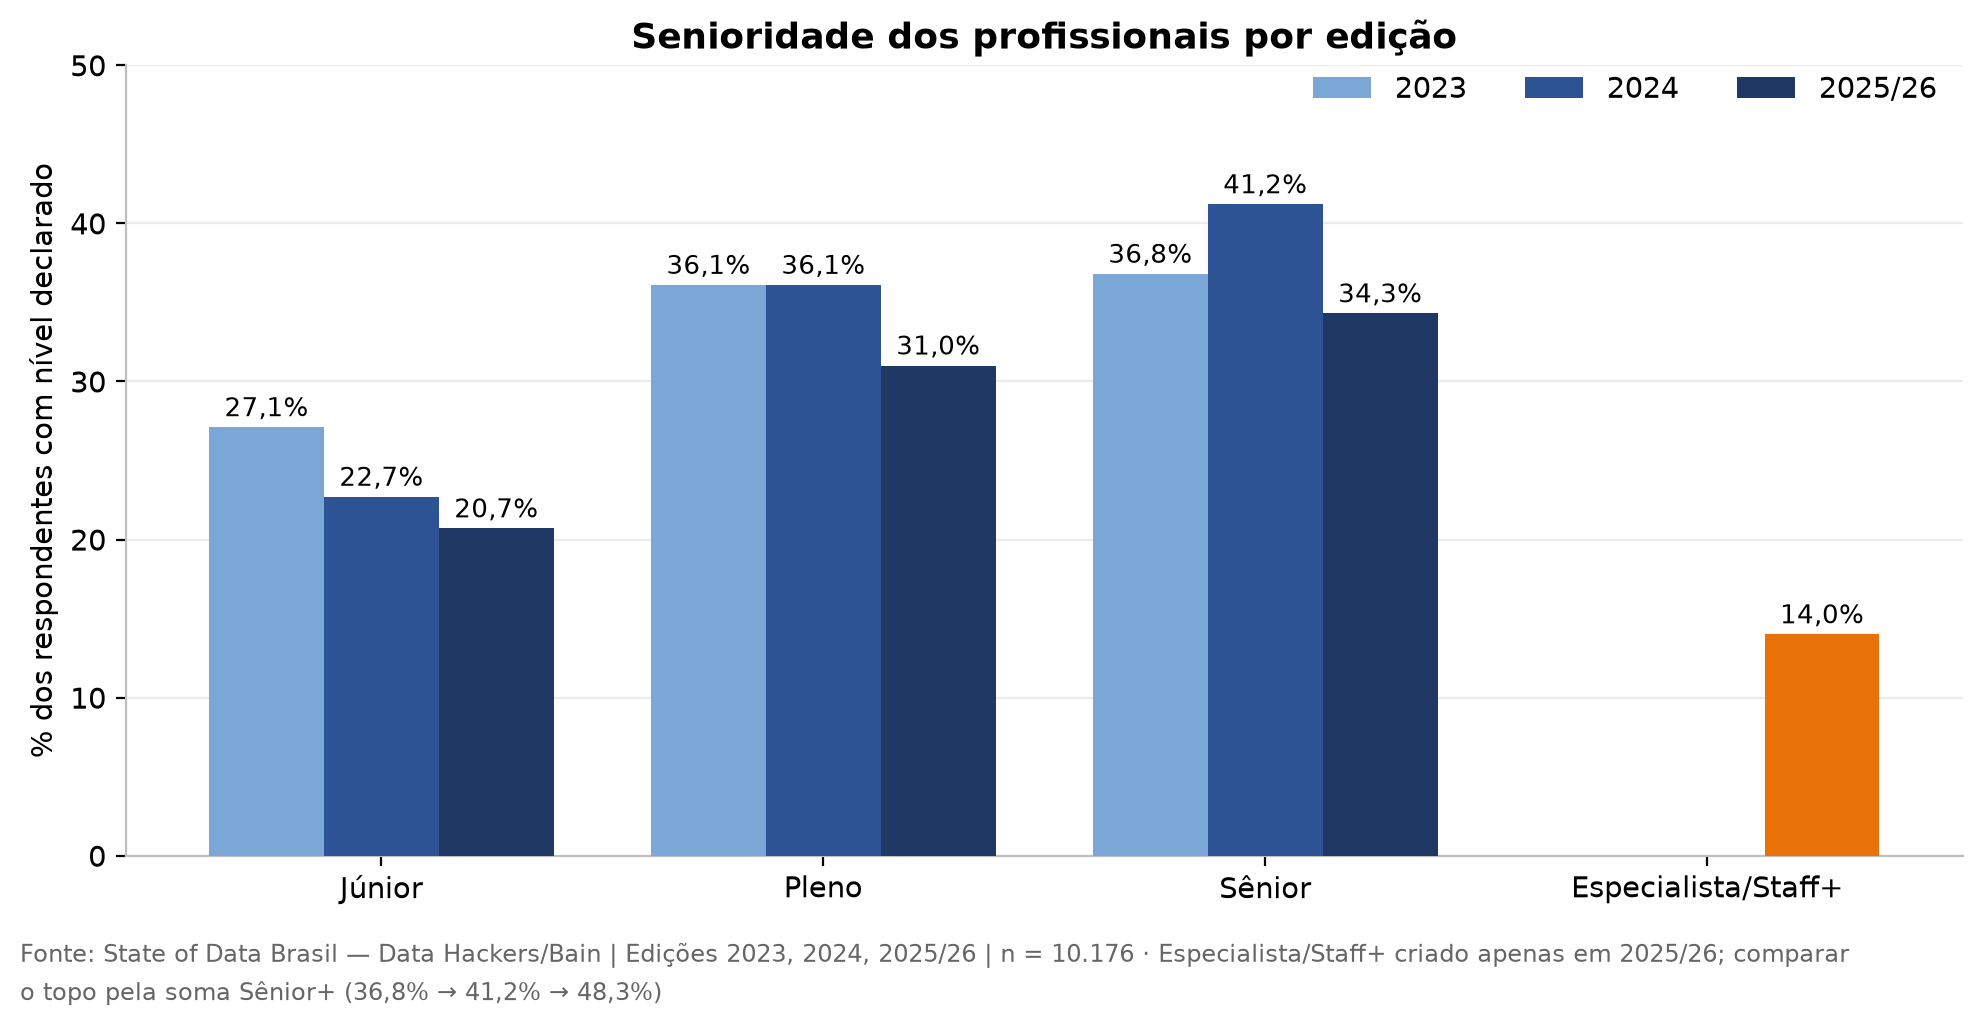

[grafico] G03_seniority_by_year


In [4]:
# G03 — Pirâmide de senioridade por edição ---------------------------------
d = ler("gold_seniority")
ordem = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]
x = range(len(ordem)); larg = 0.26

fig, ax = nova_fig()
for i, ano in enumerate(ANOS_NUCLEO):
    da = d[d.ano == ano].set_index("nivel").reindex(ordem)
    pos = [p + (i - 1) * larg for p in x]
    # Especialista/Staff+ é categoria nova (só existe em 2025/26, sem série comparável) —
    # laranja de destaque conforme docs/visual_standard.md, mesmo tratamento do G04/G07.
    cores_barra = [LARANJA if nivel == "Especialista/Staff+" else SERIE_ANOS[i] for nivel in ordem]
    ax.bar(pos, da.pct.fillna(0), width=larg, label=ROTULO_ANO[ano], color=cores_barra, zorder=3)
    for px, v in zip(pos, da.pct):
        if pd.notna(v):
            ax.text(px, v + 0.7, pct(v), ha="center", fontsize=9.5)
senior_mais = {a: d[(d.ano == a) & (d.nivel.isin(["Sênior", "Especialista/Staff+"]))].pct.sum()
               for a in ANOS_NUCLEO}
ax.set_xticks(list(x)); ax.set_xticklabels(ordem)
ax.set_title("Senioridade dos profissionais por edição")
ax.set_ylabel("% dos respondentes com nível declarado")
ax.set_ylim(0, 50)
ax.legend(ncol=3, loc="upper right", bbox_to_anchor=(1.0, 1.02))
eixo(ax)
salvar(fig, "G03_seniority_by_year", ANOS_NUCLEO, d.n.sum(),
       "Especialista/Staff+ criado apenas em 2025/26; comparar o topo pela soma Sênior+ ("
       + " → ".join(pct(senior_mais[a]) for a in ANOS_NUCLEO) + ")")

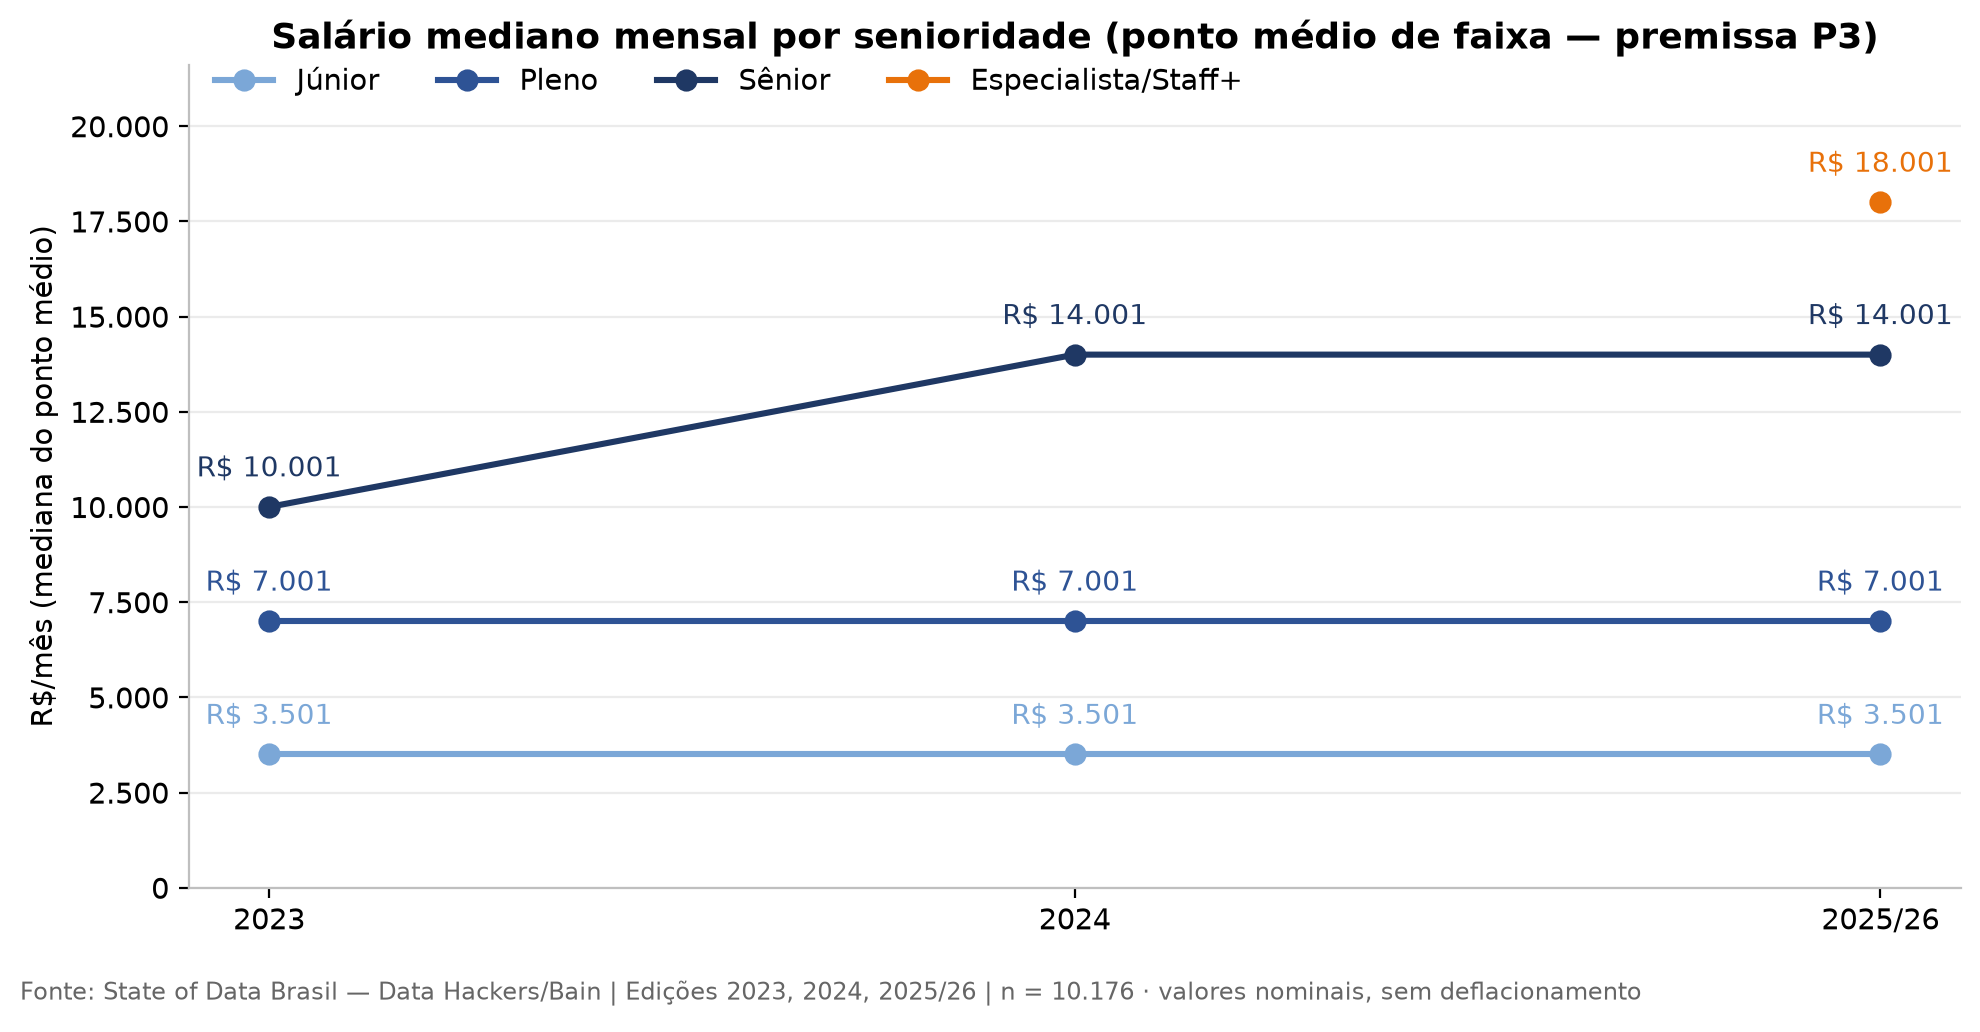

[grafico] G04_salary_by_seniority


In [5]:
# G04 — Escada salarial: mediana por senioridade e edição -------------------
d = ler("gold_salary_by_seniority")
series = [("Júnior", AZUL_CLARO), ("Pleno", AZUL_MED), ("Sênior", AZUL), ("Especialista/Staff+", LARANJA)]

fig, ax = nova_fig()
for nivel, cor in series:
    da = d[d.nivel == nivel].sort_values("ano")
    ax.plot([ROTULO_ANO[a] for a in da.ano], da.salario_mediano_pm,
            marker="o", markersize=7, linewidth=2.2, label=nivel, color=cor, zorder=3)
    for xa, v in zip([ROTULO_ANO[a] for a in da.ano], da.salario_mediano_pm):
        ax.annotate(f"R$ {mil(v)}", (xa, v), textcoords="offset points", xytext=(0, 11),
                    ha="center", fontsize=10, color=cor)
ax.set_title("Salário mediano mensal por senioridade (ponto médio de faixa — premissa P3)")
ax.set_ylabel("R$/mês (mediana do ponto médio)")
ax.set_ylim(0, d.salario_mediano_pm.max() * 1.20)
ax.yaxis.set_major_formatter(FMT_MIL)
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0.0, 1.03))
eixo(ax)
salvar(fig, "G04_salary_by_seniority", ANOS_NUCLEO, d.n.sum(), "valores nominais, sem deflacionamento")

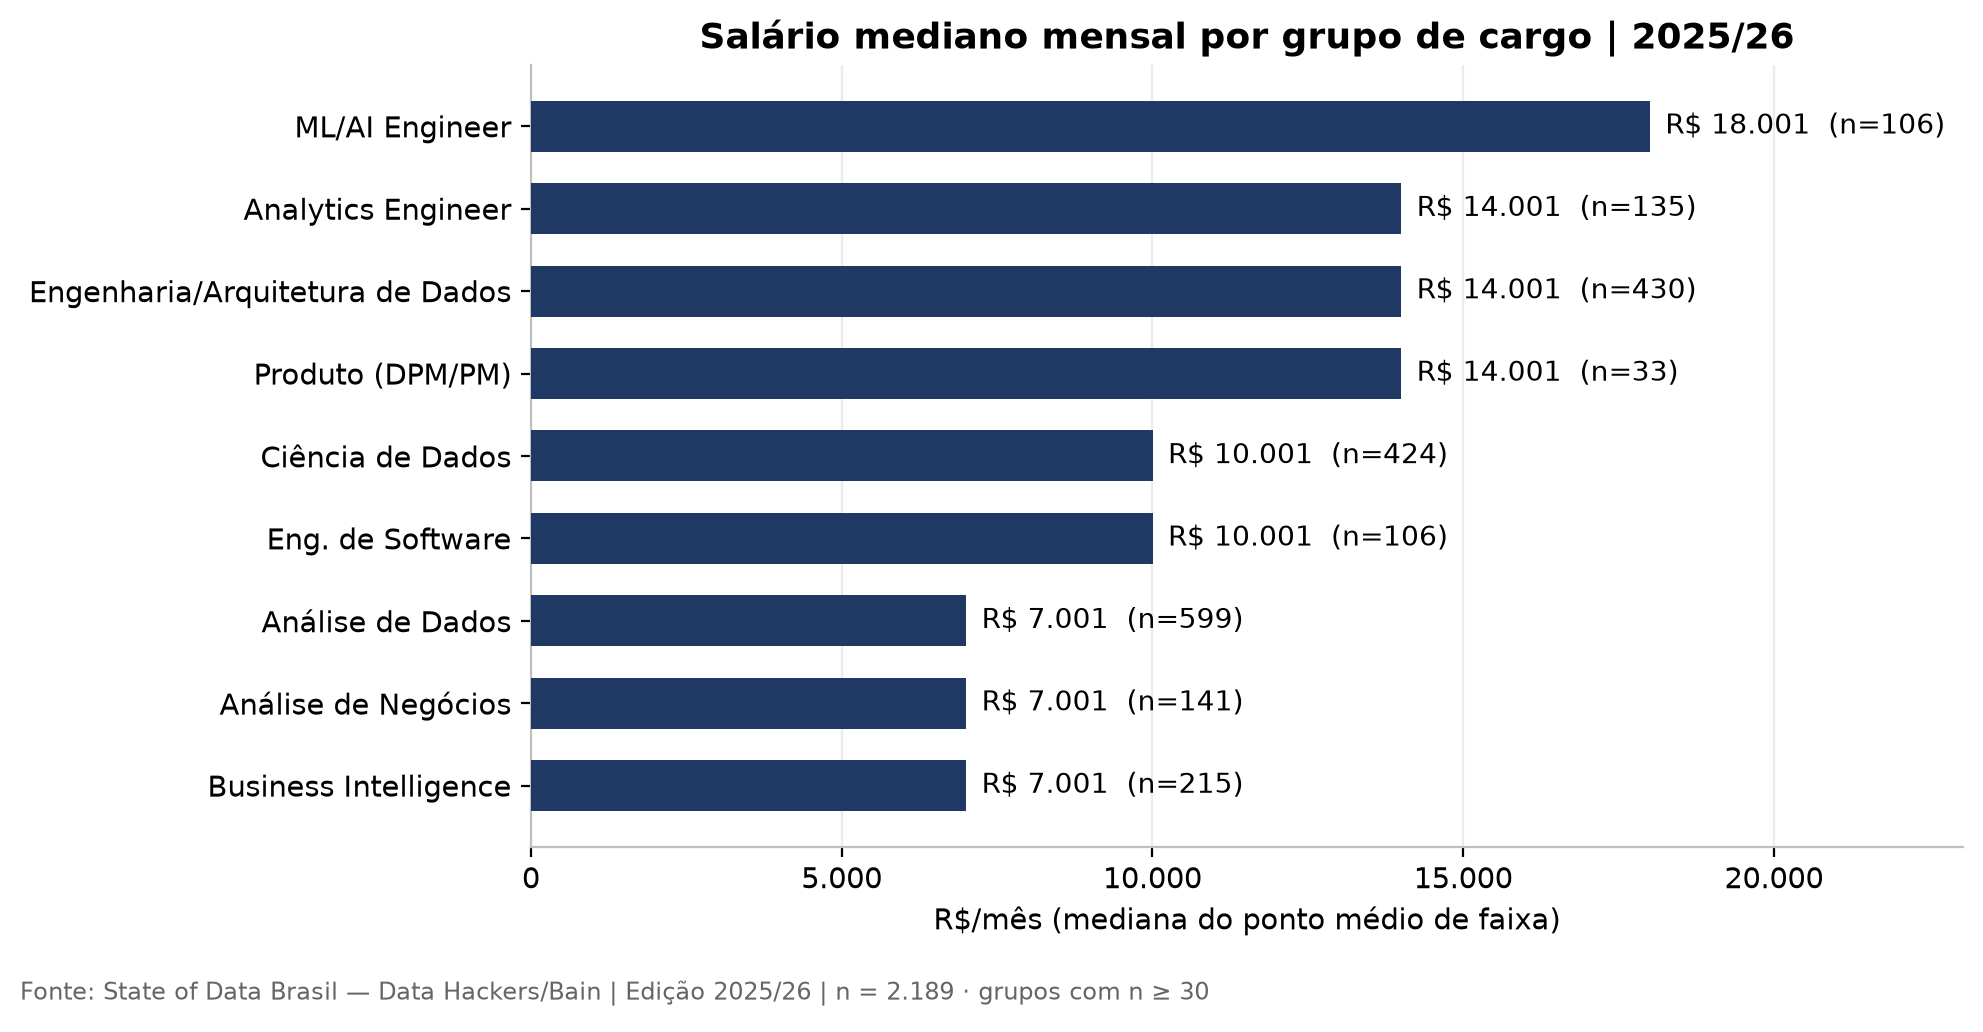

[grafico] G05_salary_by_role_2025


In [6]:
# G05 — Prêmio por especialização: mediana por grupo de cargo (n >= 30) -----
d = ler("gold_salary_by_role")
d25 = d[(d.ano == 2025) & (d.n >= 30)].nlargest(9, "salario_mediano_pm").sort_values("salario_mediano_pm")

fig, ax = nova_fig()
ax.barh(d25.cargo_grupo, d25.salario_mediano_pm, color=AZUL, height=0.62, zorder=3)
for y, (v, n) in enumerate(zip(d25.salario_mediano_pm, d25.n)):
    ax.text(v + 250, y, f"R$ {mil(v)}  (n={n})", va="center", fontsize=10)
ax.set_title("Salário mediano mensal por grupo de cargo | 2025/26")
ax.set_xlabel("R$/mês (mediana do ponto médio de faixa)")
ax.set_xlim(0, d25.salario_mediano_pm.max() * 1.28)
ax.xaxis.set_major_formatter(FMT_MIL)
eixo(ax, valor="x")
salvar(fig, "G05_salary_by_role_2025", [2025], d25.n.sum(), "grupos com n ≥ 30")

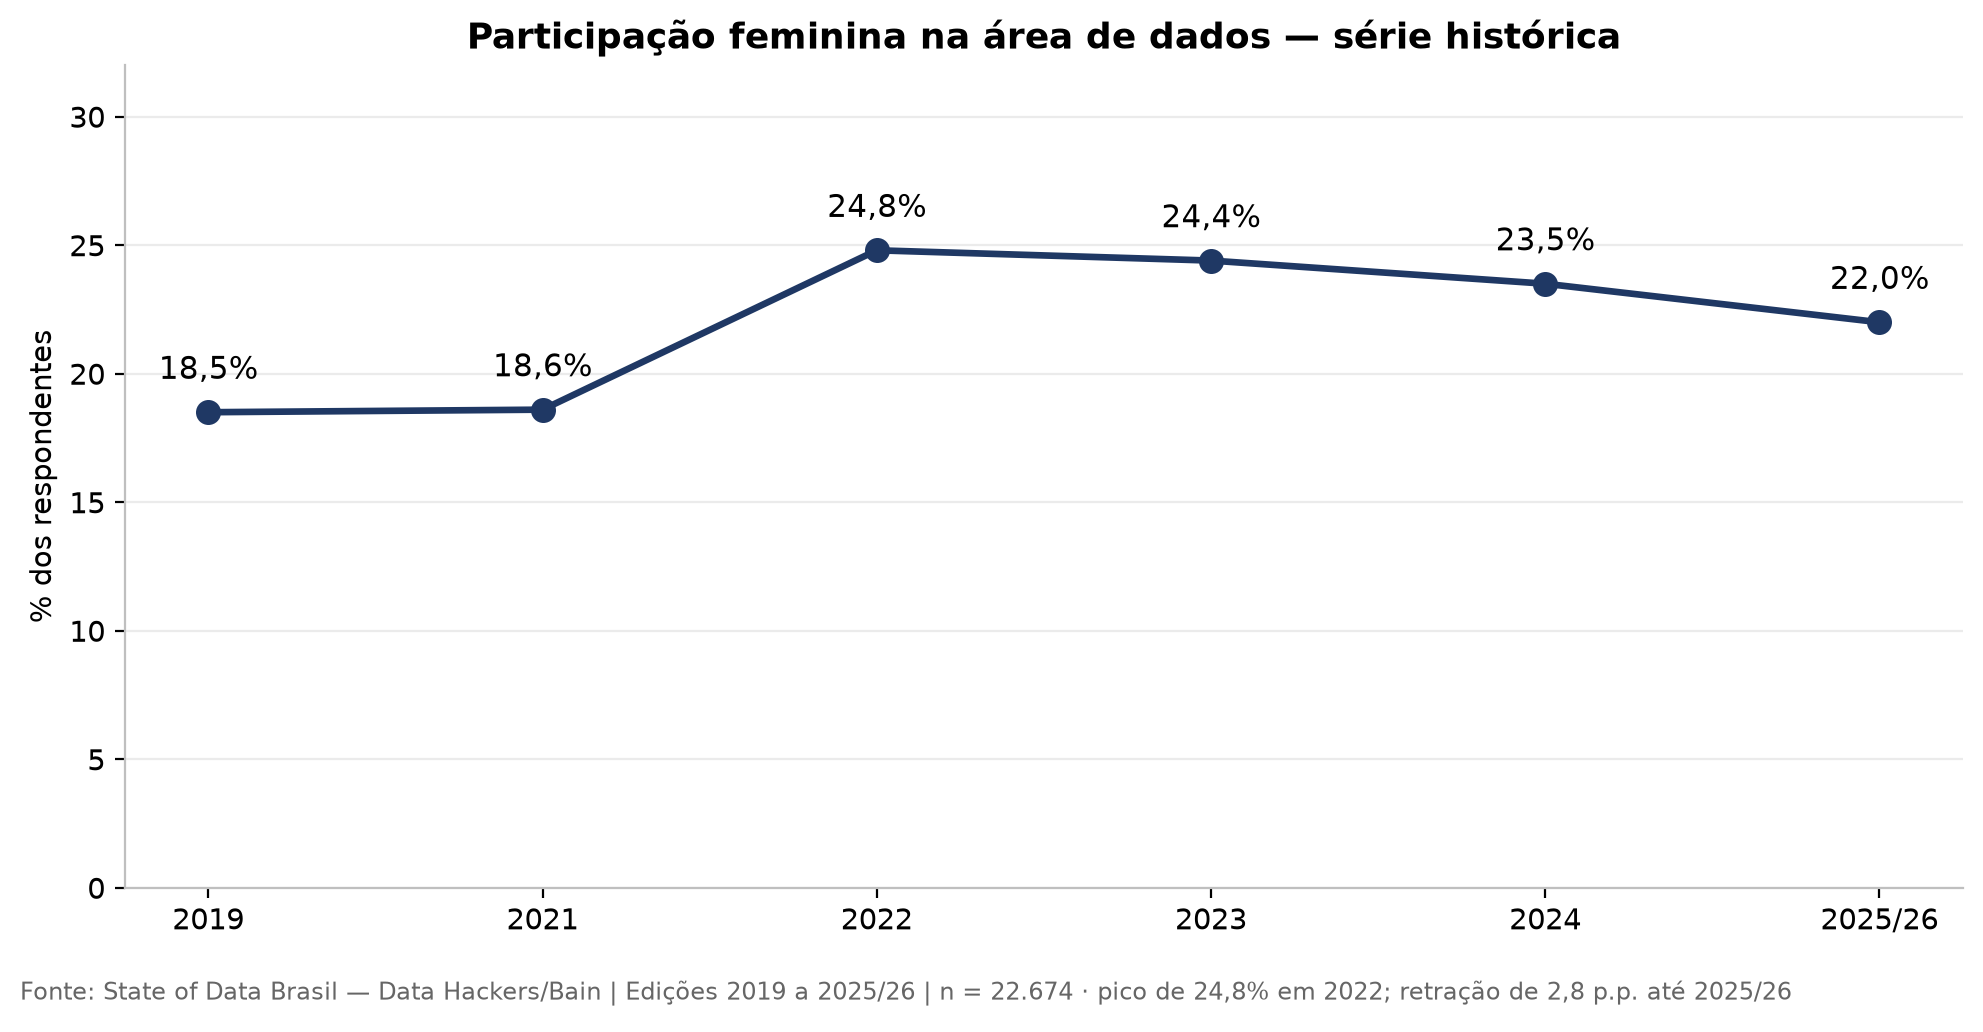

[grafico] G06_female_participation


In [7]:
# G06 — Participação feminina: série histórica 2019 -> 2025/26 --------------
d = ler("gold_gender_participation")
f = d[d.genero == "Feminino"].sort_values("ano")

fig, ax = nova_fig()
ax.plot([ROTULO_ANO[a] for a in f.ano], f.pct, marker="o", markersize=8, linewidth=2.4,
        color=AZUL, zorder=3)
for xa, v in zip([ROTULO_ANO[a] for a in f.ano], f.pct):
    ax.annotate(pct(v), (xa, v), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=11)
pico, atual = f.pct.max(), f.pct.iloc[-1]
ax.set_title("Participação feminina na área de dados — série histórica")
ax.set_ylabel("% dos respondentes")
ax.set_ylim(0, 32)
eixo(ax)
salvar(fig, "G06_female_participation", f.ano.tolist(), d.n.sum(),
       f"pico de {pct(pico)} em 2022; retração de {pct(pico - atual)[:-1]} p.p. até 2025/26")

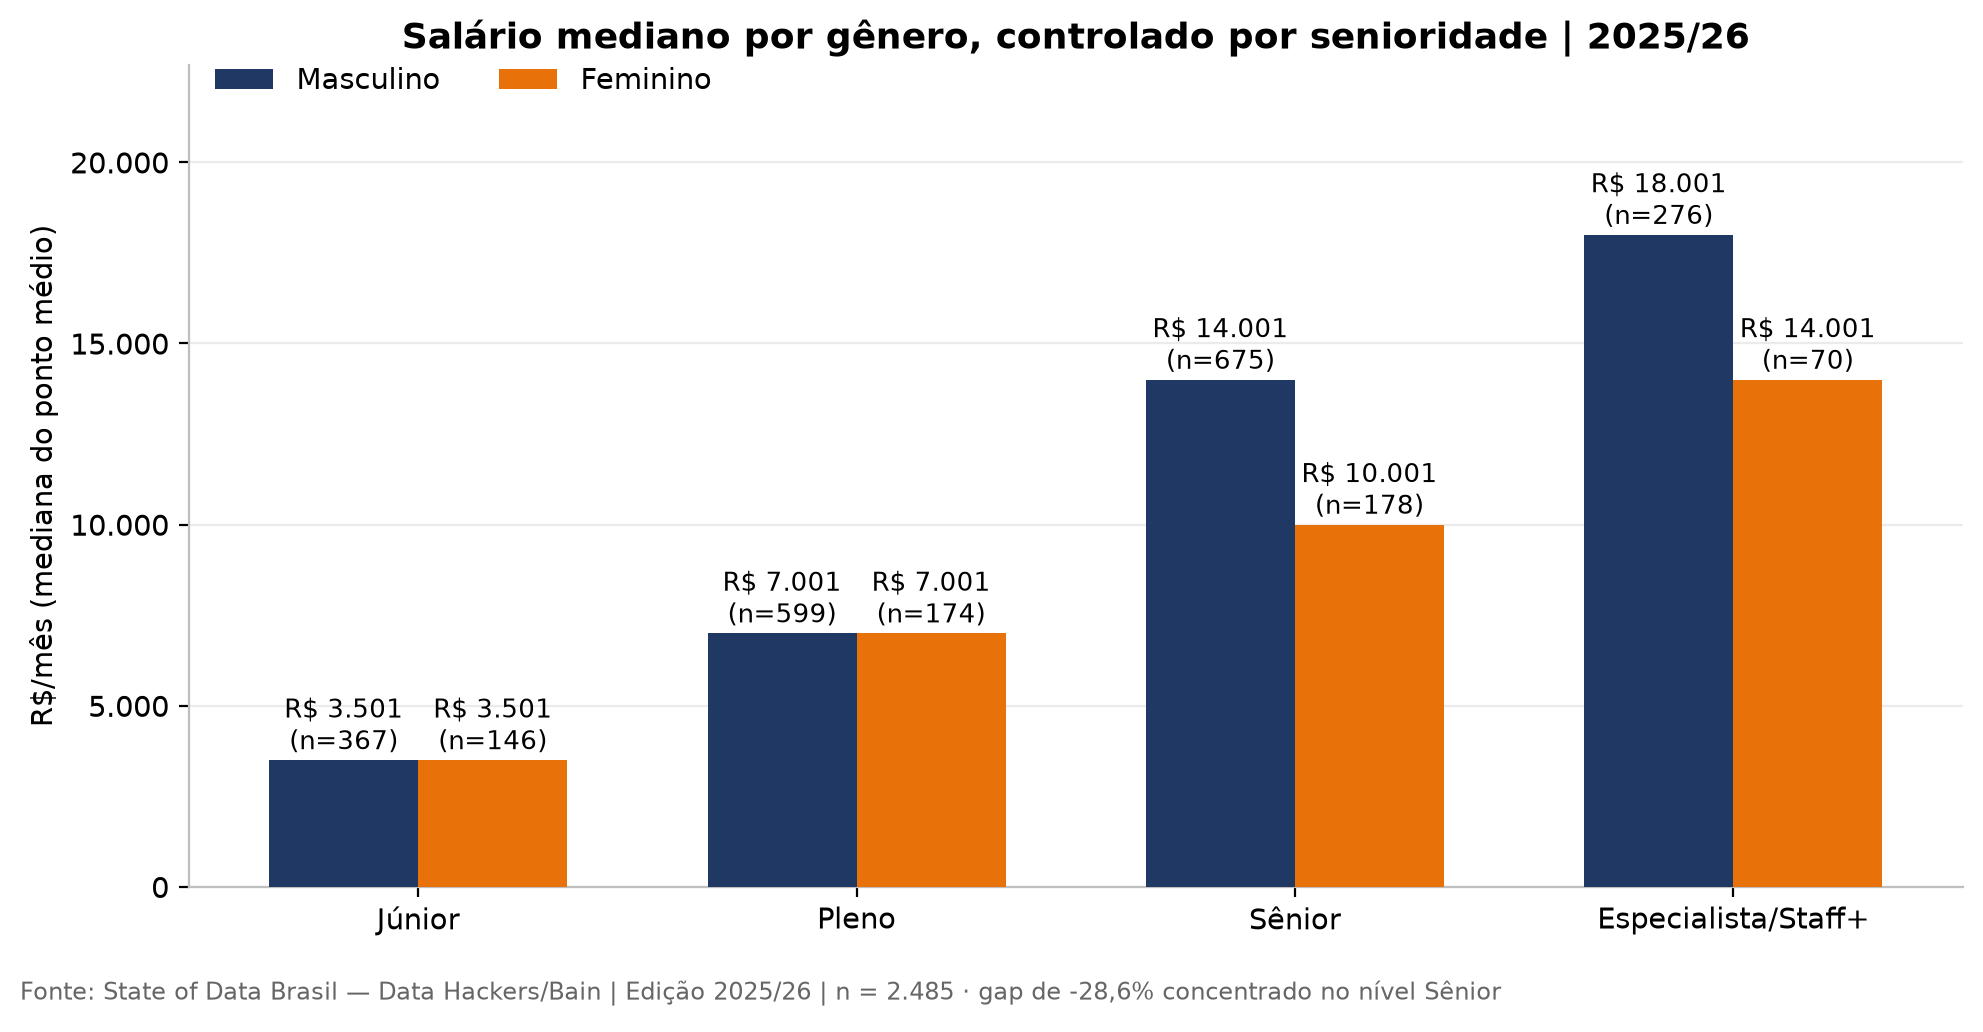

[grafico] G07_gender_gap_by_seniority


In [8]:
# G07 — Gap de gênero controlado por senioridade (2025/26) ------------------
d = ler("gold_gender_seniority_salary"); d25 = d[d.ano == 2025]
ordem = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]
x = range(len(ordem)); larg = 0.34

fig, ax = nova_fig()
for i, (gen, cor) in enumerate([("Masculino", AZUL), ("Feminino", LARANJA)]):
    da = d25[d25.genero == gen].set_index("nivel").reindex(ordem)
    pos = [p + (i - 0.5) * larg for p in x]
    ax.bar(pos, da.salario_mediano_pm, width=larg, label=gen, color=cor, zorder=3)
    for px, (v, n) in zip(pos, zip(da.salario_mediano_pm, da.n)):
        if pd.notna(v):
            ax.text(px, v + 300, f"R$ {mil(v)}\n(n={int(n)})", ha="center", fontsize=9.5)
sen = d25[d25.nivel == "Sênior"].set_index("genero").salario_mediano_pm
gap = 100 * (sen["Feminino"] / sen["Masculino"] - 1)
ax.set_xticks(list(x)); ax.set_xticklabels(ordem)
ax.set_title("Salário mediano por gênero, controlado por senioridade | 2025/26")
ax.set_ylabel("R$/mês (mediana do ponto médio)")
ax.set_ylim(0, d25.salario_mediano_pm.max() * 1.26)
ax.yaxis.set_major_formatter(FMT_MIL)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(0.0, 1.03))
eixo(ax)
salvar(fig, "G07_gender_gap_by_seniority", [2025], d25.n.sum(), f"gap de {pct(gap)} concentrado no nível Sênior")

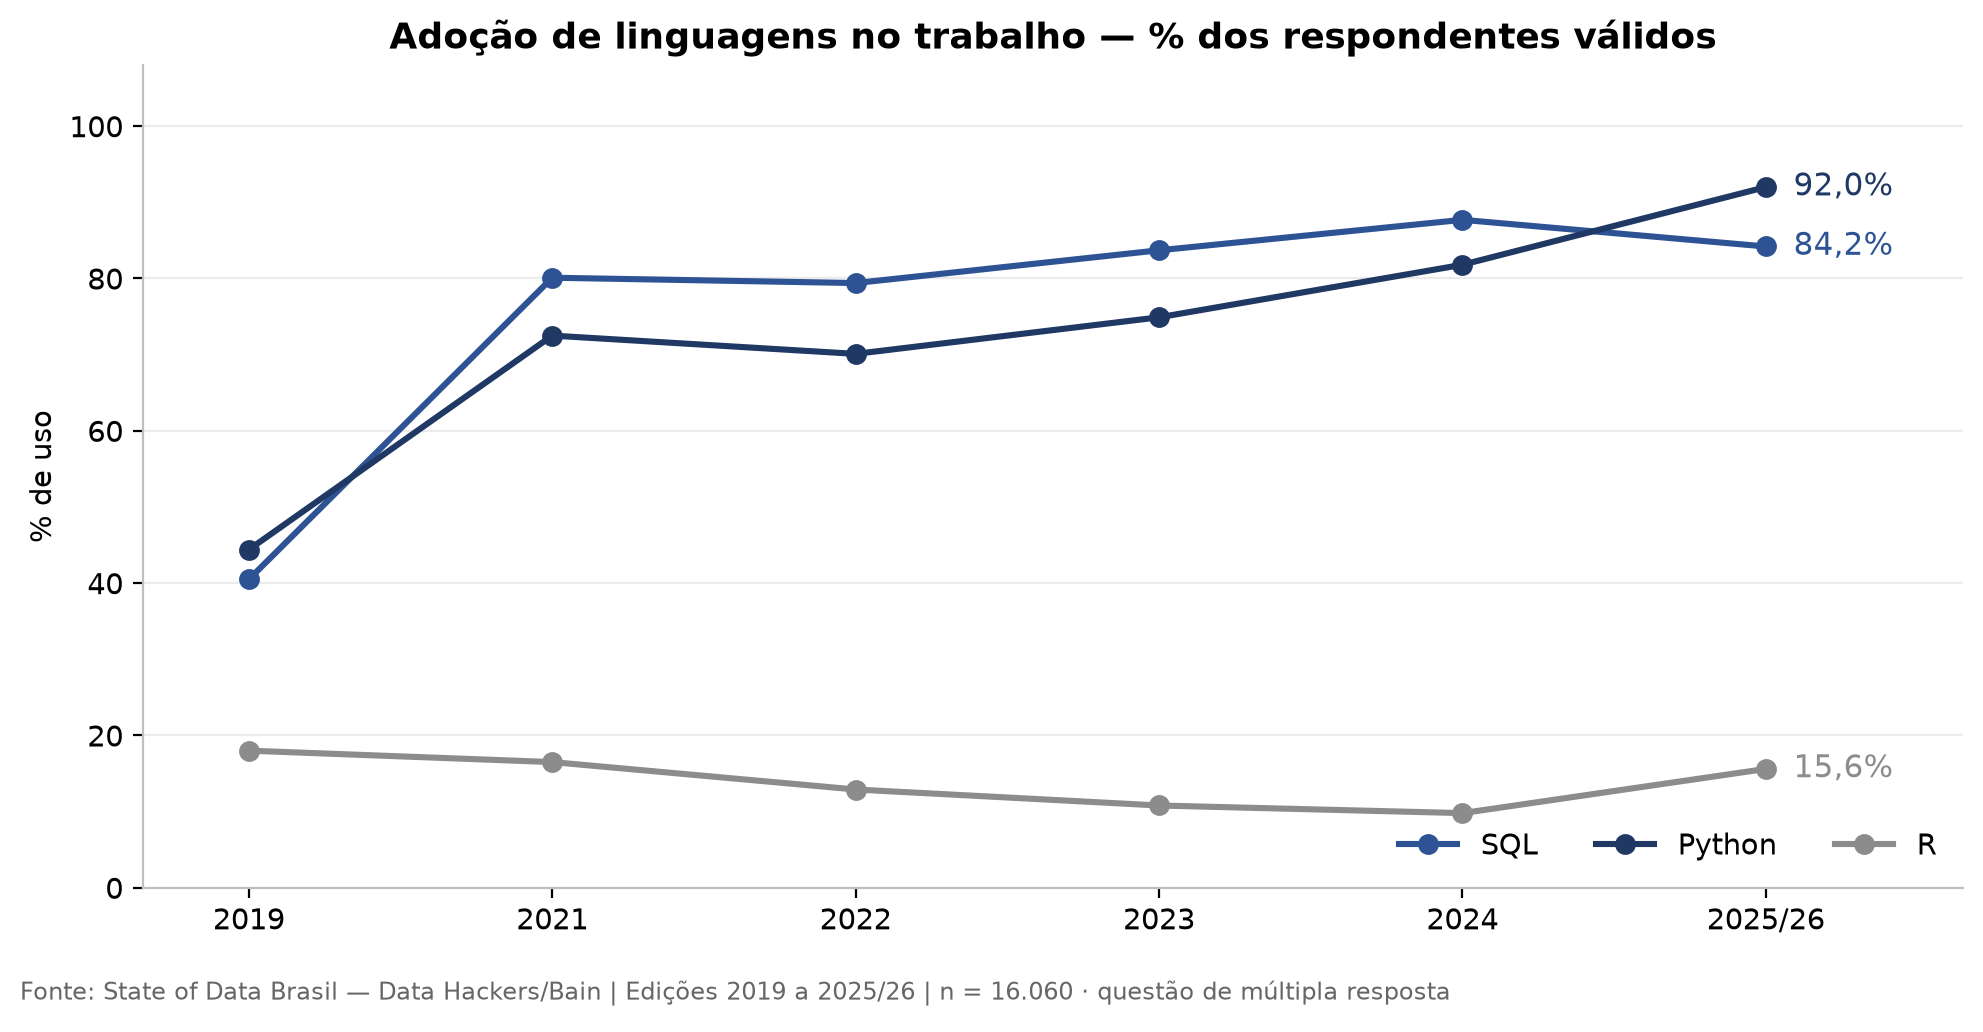

[grafico] G08_languages_series


In [9]:
# G08 — Linguagens: série 2019 -> 2025/26 -----------------------------------
d = ler("gold_technologies"); dl = d[d.categoria == "linguagem"]

fig, ax = nova_fig()
for tec, cor in [("SQL", AZUL_MED), ("Python", AZUL), ("R", CINZA)]:
    da = dl[dl.tecnologia == tec].sort_values("ano")
    rot = [ROTULO_ANO[a] for a in da.ano]
    ax.plot(rot, da.pct, marker="o", markersize=6.5, linewidth=2.2, label=tec, color=cor, zorder=3)
    ax.annotate(pct(da.pct.iloc[-1]), (rot[-1], da.pct.iloc[-1]), textcoords="offset points",
                xytext=(10, -3), fontsize=11, color=cor)
ax.set_title("Adoção de linguagens no trabalho — % dos respondentes válidos")
ax.set_ylabel("% de uso")
ax.set_ylim(0, 108)
ax.set_xlim(-0.35, len(ROTULO_ANO) - 0.35)
ax.legend(ncol=3, loc="lower right")
eixo(ax)
salvar(fig, "G08_languages_series", sorted(dl.ano.unique()), dl[dl.tecnologia == "Python"].base_valida.sum(),
       "questão de múltipla resposta")

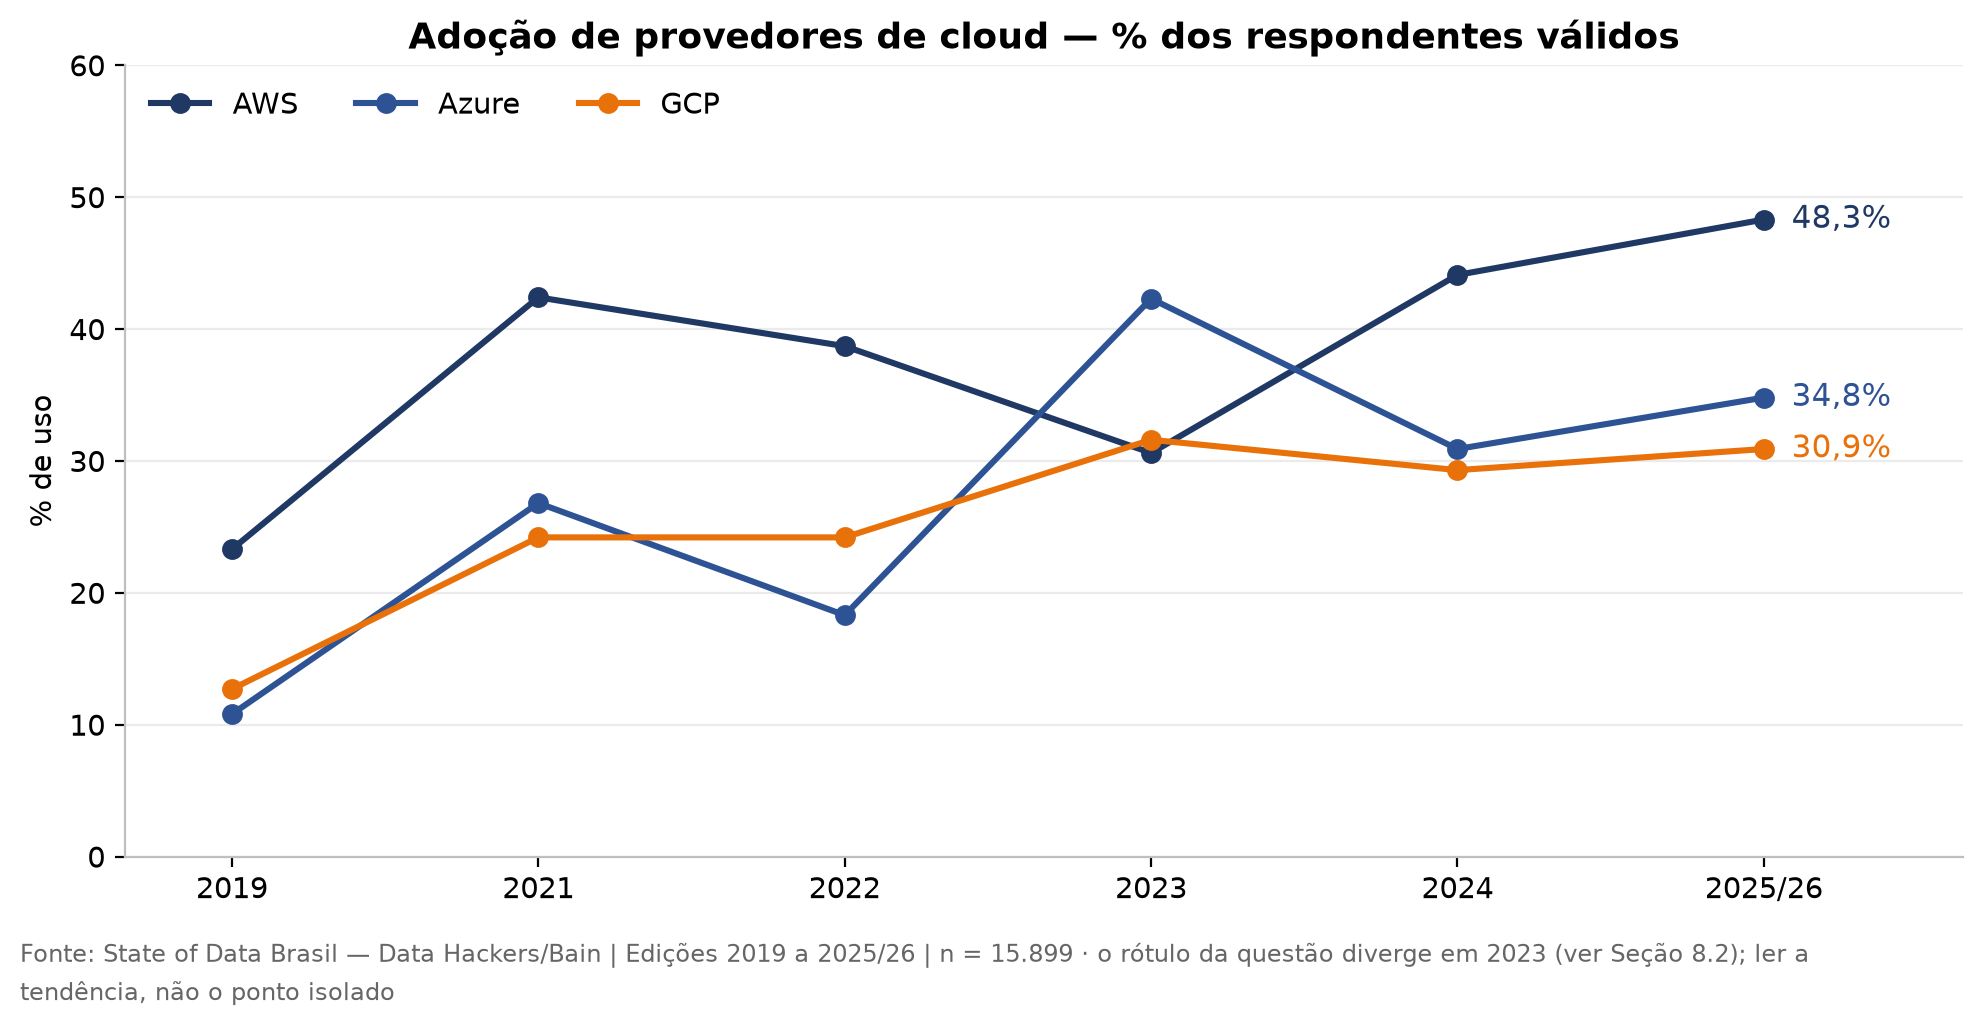

[grafico] G09_cloud_providers_series


In [10]:
# G09 — Provedores de cloud: série 2019 -> 2025/26 --------------------------
dc = ler("gold_technologies"); dc = dc[dc.categoria == "cloud"]

fig, ax = nova_fig()
for tec, cor in [("AWS", AZUL), ("Azure", AZUL_MED), ("GCP", LARANJA)]:
    da = dc[dc.tecnologia == tec].sort_values("ano")
    rot = [ROTULO_ANO[a] for a in da.ano]
    ax.plot(rot, da.pct, marker="o", markersize=6.5, linewidth=2.2, label=tec, color=cor, zorder=3)
    ax.annotate(pct(da.pct.iloc[-1]), (rot[-1], da.pct.iloc[-1]), textcoords="offset points",
                xytext=(10, -3), fontsize=11, color=cor)
ax.set_title("Adoção de provedores de cloud — % dos respondentes válidos")
ax.set_ylabel("% de uso")
ax.set_ylim(0, 60)
ax.set_xlim(-0.35, len(ROTULO_ANO) - 0.35)
ax.legend(ncol=3, loc="upper left")
eixo(ax)
salvar(fig, "G09_cloud_providers_series", sorted(dc.ano.unique()), dc[dc.tecnologia == "AWS"].base_valida.sum(),
       "o rótulo da questão diverge em 2023 (ver Seção 8.2); ler a tendência, não o ponto isolado")

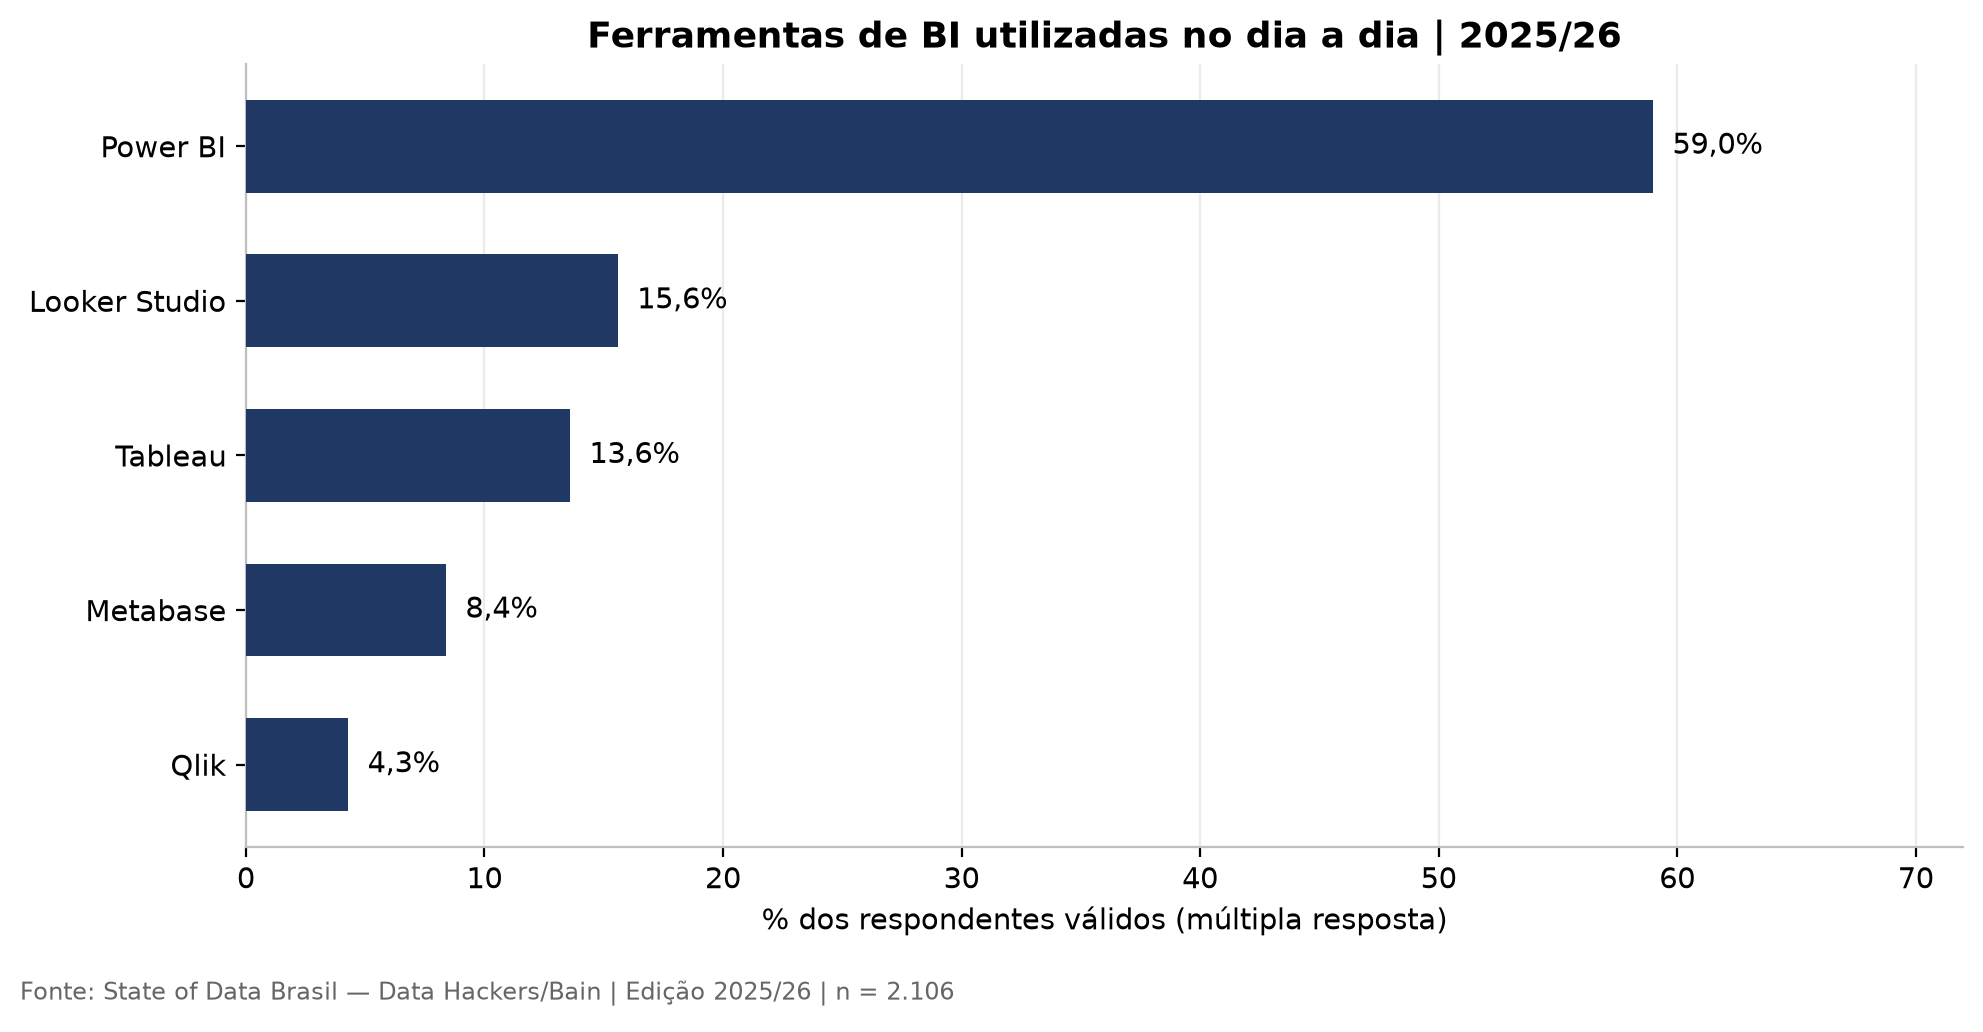

[grafico] G10_bi_tools_2025


In [11]:
# G10 — Ferramentas de BI (2025/26) -----------------------------------------
d = ler("gold_technologies")
db = d[(d.categoria == "bi") & (d.ano == 2025)].sort_values("pct")

fig, ax = nova_fig()
ax.barh(db.tecnologia, db.pct, color=AZUL, height=0.6, zorder=3)
for y, v in enumerate(db.pct):
    ax.text(v + 0.8, y, pct(v), va="center", fontsize=10.5)
ax.set_title("Ferramentas de BI utilizadas no dia a dia | 2025/26")
ax.set_xlabel("% dos respondentes válidos (múltipla resposta)")
ax.set_xlim(0, db.pct.max() * 1.22)
eixo(ax, valor="x")
salvar(fig, "G10_bi_tools_2025", [2025], db.base_valida.max())

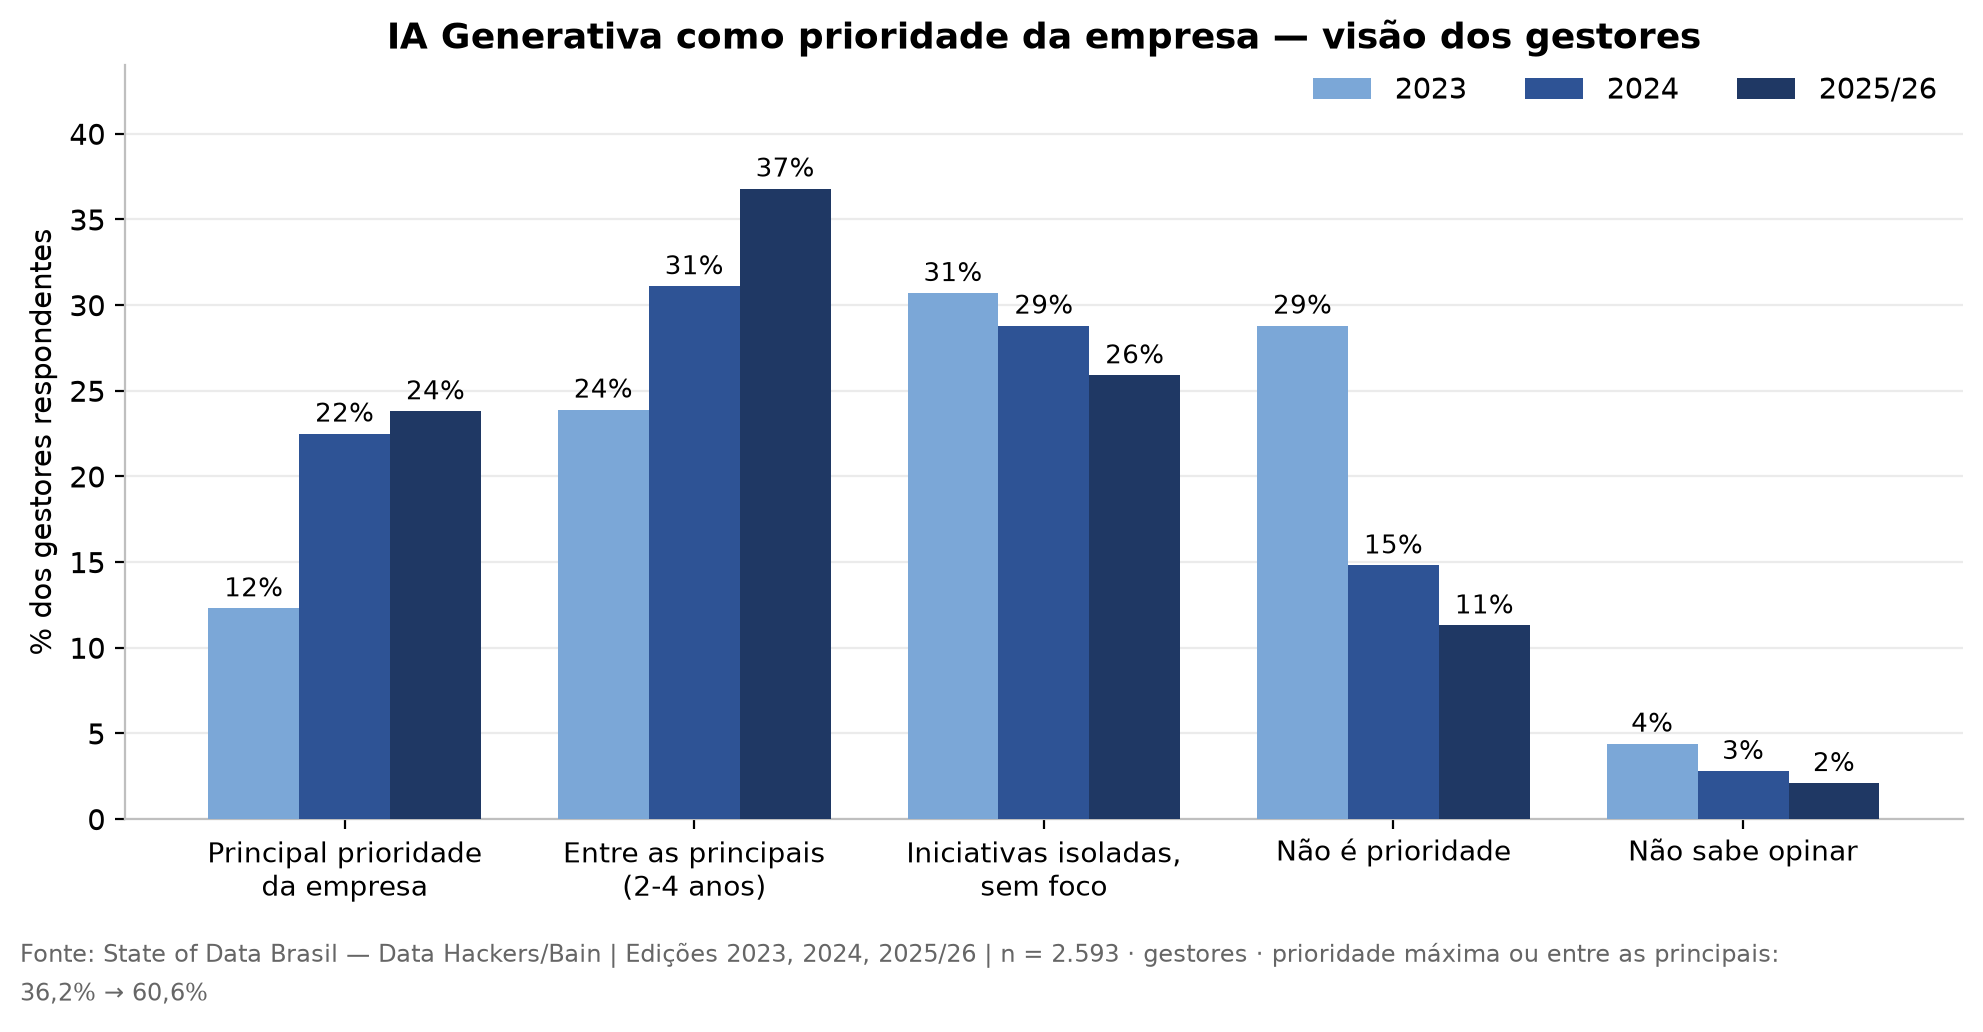

[grafico] G11_ai_priority


In [12]:
# G11 — IA generativa como prioridade da empresa (visão dos gestores) -------
d = ler("gold_ai_priority")
cats = sorted(d.prioridade_ia_h.unique())
rotulos = [c.split(". ", 1)[1].replace(" (2-4 anos)", "\n(2-4 anos)").replace(", sem foco", ",\nsem foco").replace("Principal prioridade da empresa", "Principal prioridade\nda empresa")
           for c in cats]
x = range(len(cats)); larg = 0.26

fig, ax = nova_fig()
for i, ano in enumerate(ANOS_NUCLEO):
    da = d[d.ano == ano].set_index("prioridade_ia_h").reindex(cats)
    pos = [p + (i - 1) * larg for p in x]
    ax.bar(pos, da.pct.fillna(0), width=larg, label=ROTULO_ANO[ano], color=SERIE_ANOS[i], zorder=3)
    for px, v in zip(pos, da.pct):
        if pd.notna(v):
            ax.text(px, v + 0.7, f"{v:.0f}%", ha="center", fontsize=9.5)
top2 = {a: d[(d.ano == a) & (d.prioridade_ia_h.str.startswith(("1.", "2.")))].pct.sum()
        for a in ANOS_NUCLEO}
ax.set_xticks(list(x)); ax.set_xticklabels(rotulos, fontsize=10)
ax.set_title("IA Generativa como prioridade da empresa — visão dos gestores")
ax.set_ylabel("% dos gestores respondentes")
ax.set_ylim(0, 44)
ax.legend(ncol=3, loc="upper right", bbox_to_anchor=(1.0, 1.02))
eixo(ax)
salvar(fig, "G11_ai_priority", ANOS_NUCLEO, d.n.sum(),
       f"gestores · prioridade máxima ou entre as principais: {pct(top2[2023])} → {pct(top2[2025])}")

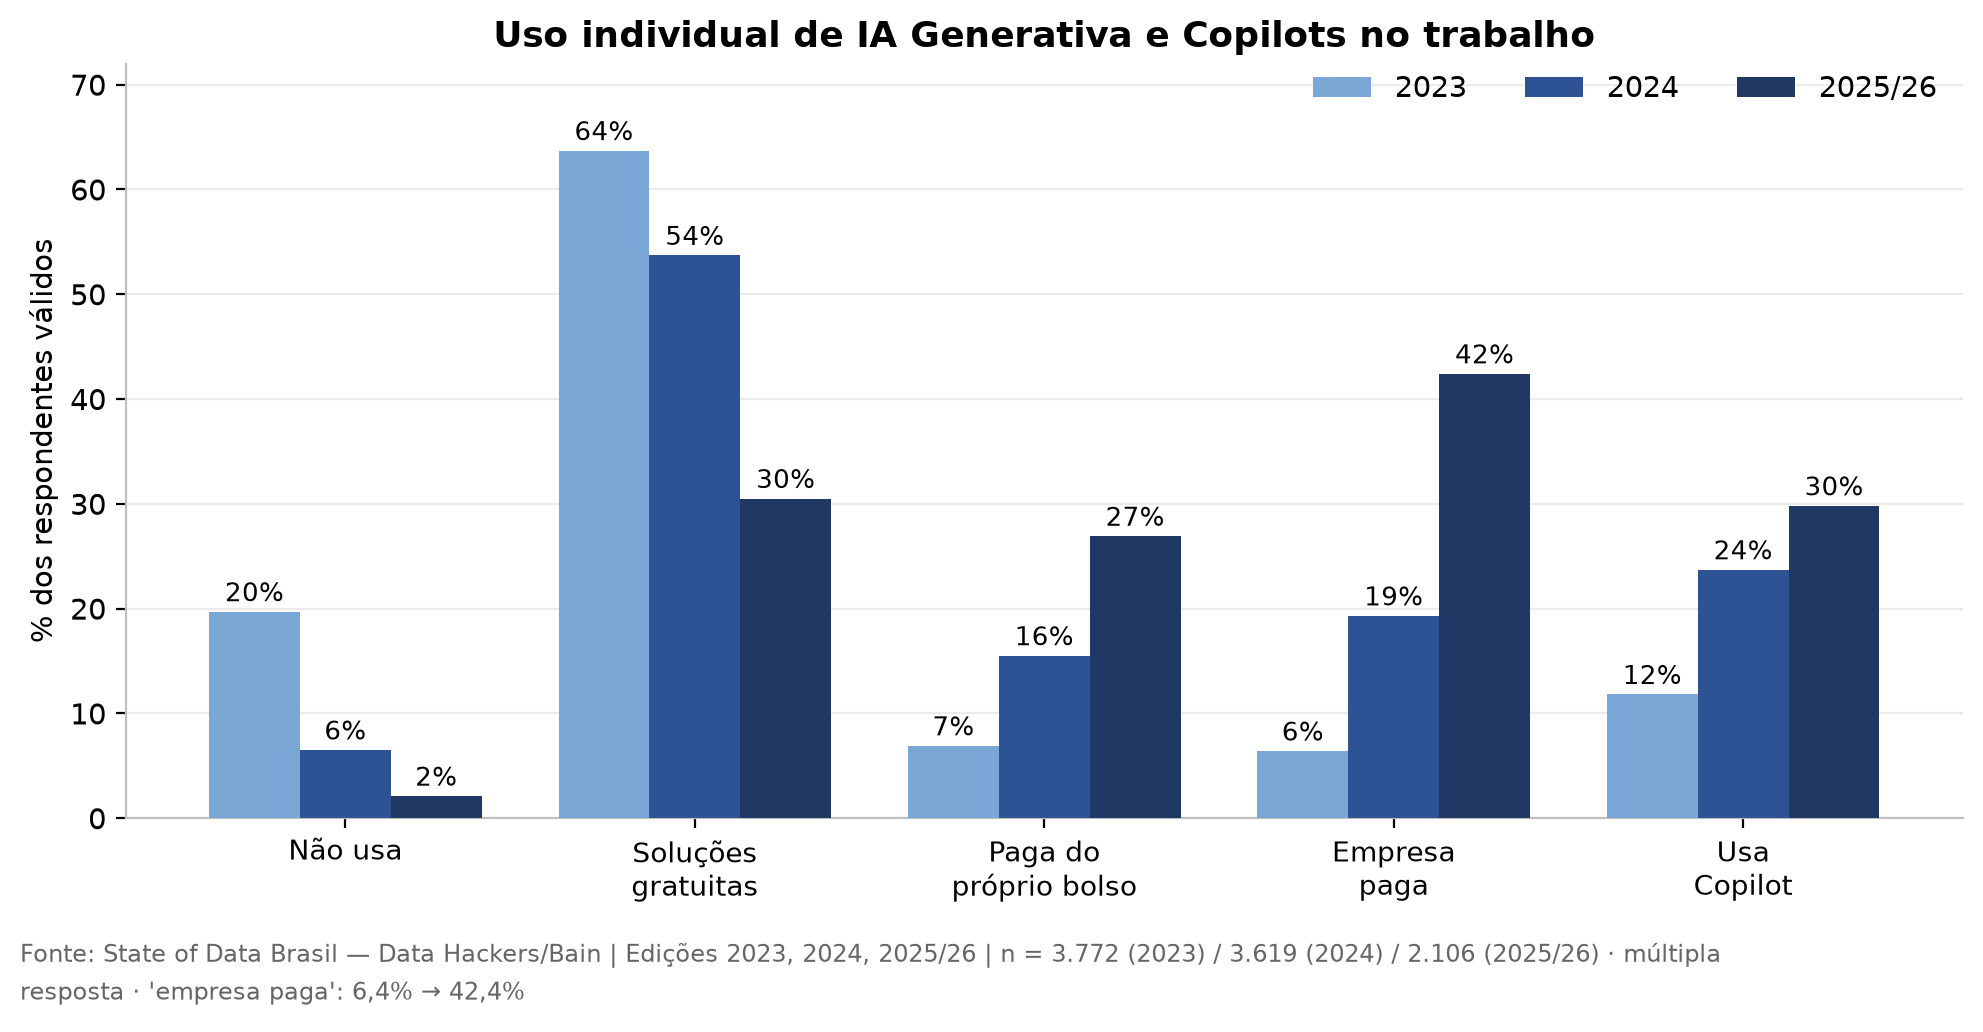

[grafico] G12_genai_usage


In [13]:
# G12 — Uso individual de GenAI e Copilots ----------------------------------
d = ler("gold_genai_usage")
ordem = ["Não usa GenAI", "Usa soluções gratuitas", "Paga do próprio bolso", "Empresa paga", "Usa Copilot"]
rotulos = ["Não usa", "Soluções\ngratuitas", "Paga do\npróprio bolso", "Empresa\npaga", "Usa\nCopilot"]
x = range(len(ordem)); larg = 0.26

fig, ax = nova_fig()
for i, ano in enumerate(ANOS_NUCLEO):
    da = d[d.ano == ano].set_index("modalidade").reindex(ordem)
    pos = [p + (i - 1) * larg for p in x]
    ax.bar(pos, da.pct.fillna(0), width=larg, label=ROTULO_ANO[ano], color=SERIE_ANOS[i], zorder=3)
    for px, v in zip(pos, da.pct):
        if pd.notna(v):
            ax.text(px, v + 1.0, f"{v:.0f}%", ha="center", fontsize=9.5)
emp = d[d.modalidade == "Empresa paga"].set_index("ano").pct
ax.set_xticks(list(x)); ax.set_xticklabels(rotulos, fontsize=10)
ax.set_title("Uso individual de IA Generativa e Copilots no trabalho")
ax.set_ylabel("% dos respondentes válidos")
ax.set_ylim(0, 72)
ax.legend(ncol=3, loc="upper right", bbox_to_anchor=(1.0, 1.02))
eixo(ax)
# n varia por edição (a base da pergunta encolhe junto com a amostra: 3.772 -> 3.619 -> 2.106);
# um único "n = 3.772" (o maior valor) esconderia que o dado mais citado do relatório (42,4% em
# 2025/26) descansa sobre uma base 44% menor — por isso mostramos o n de cada edição no rodapé.
n_por_ano = " / ".join(f"{mil(int(d[d.ano == a].base_valida.max()))} ({ROTULO_ANO[a]})" for a in ANOS_NUCLEO)
salvar(fig, "G12_genai_usage", ANOS_NUCLEO, n_por_ano,
       f"múltipla resposta · 'empresa paga': {pct(emp[2023])} → {pct(emp[2025])}")

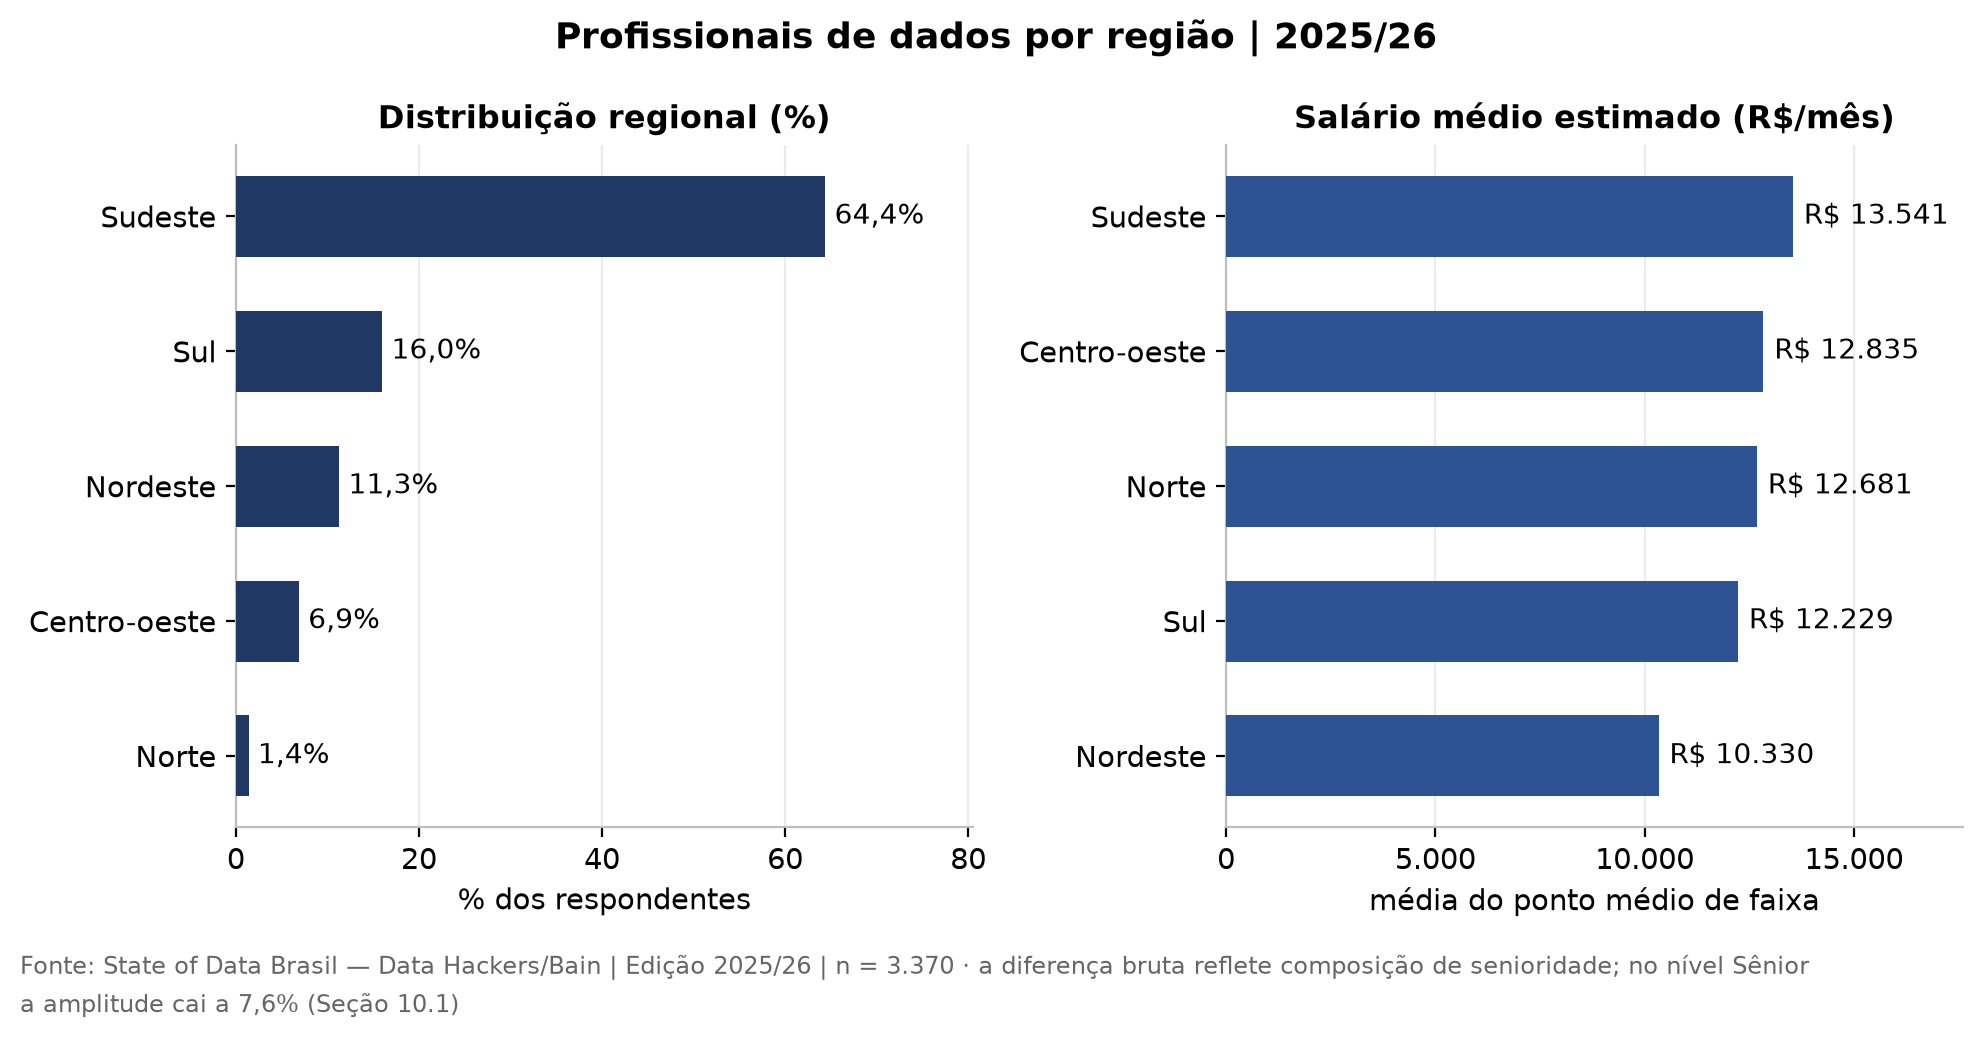

[grafico] G13_regions_2025


In [14]:
# G13 — Regiões: distribuição e salário médio estimado (2025/26) ------------
d = ler("gold_regions"); d25 = d[d.ano == 2025]
dist = d25.sort_values("n"); sal = d25.sort_values("salario_medio_pm")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 5.2))
a1.barh(dist.regiao, dist.pct, color=AZUL, height=0.6, zorder=3)
for y, v in enumerate(dist.pct):
    a1.text(v + 1.0, y, pct(v), va="center", fontsize=10)
a1.set_title("Distribuição regional (%)", fontsize=11.5)
a1.set_xlabel("% dos respondentes")
a1.set_xlim(0, dist.pct.max() * 1.25)
eixo(a1, valor="x")

a2.barh(sal.regiao, sal.salario_medio_pm, color=AZUL_MED, height=0.6, zorder=3)
for y, v in enumerate(sal.salario_medio_pm):
    a2.text(v + 260, y, f"R$ {mil(v)}", va="center", fontsize=10)
a2.set_title("Salário médio estimado (R$/mês)", fontsize=11.5)
a2.set_xlabel("média do ponto médio de faixa")
a2.set_xlim(0, sal.salario_medio_pm.max() * 1.30)
a2.set_xticks([0, 5000, 10000, 15000])          # menos ticks: rótulos não colidem
a2.xaxis.set_major_formatter(FMT_MIL)
eixo(a2, valor="x")

fig.suptitle("Profissionais de dados por região | 2025/26", fontweight="bold", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 0.99])

# Amplitude controlada por senioridade (Seção 10.1) — recalculada da própria camada Gold,
# não hardcoded, para não ficar obsoleta silenciosamente numa reexecução com dados atualizados.
rs = ler("gold_regions_by_seniority")
rs25 = rs[(rs.ano == 2025) & (rs.n_senior >= 30)]
amplitude_sen = 100 * (rs25.salario_medio_pm_senior.max() / rs25.salario_medio_pm_senior.min() - 1)
salvar(fig, "G13_regions_2025", [2025], d25.n.sum(),
       f"a diferença bruta reflete composição de senioridade; no nível Sênior a amplitude cai a {pct(amplitude_sen)} (Seção 10.1)")

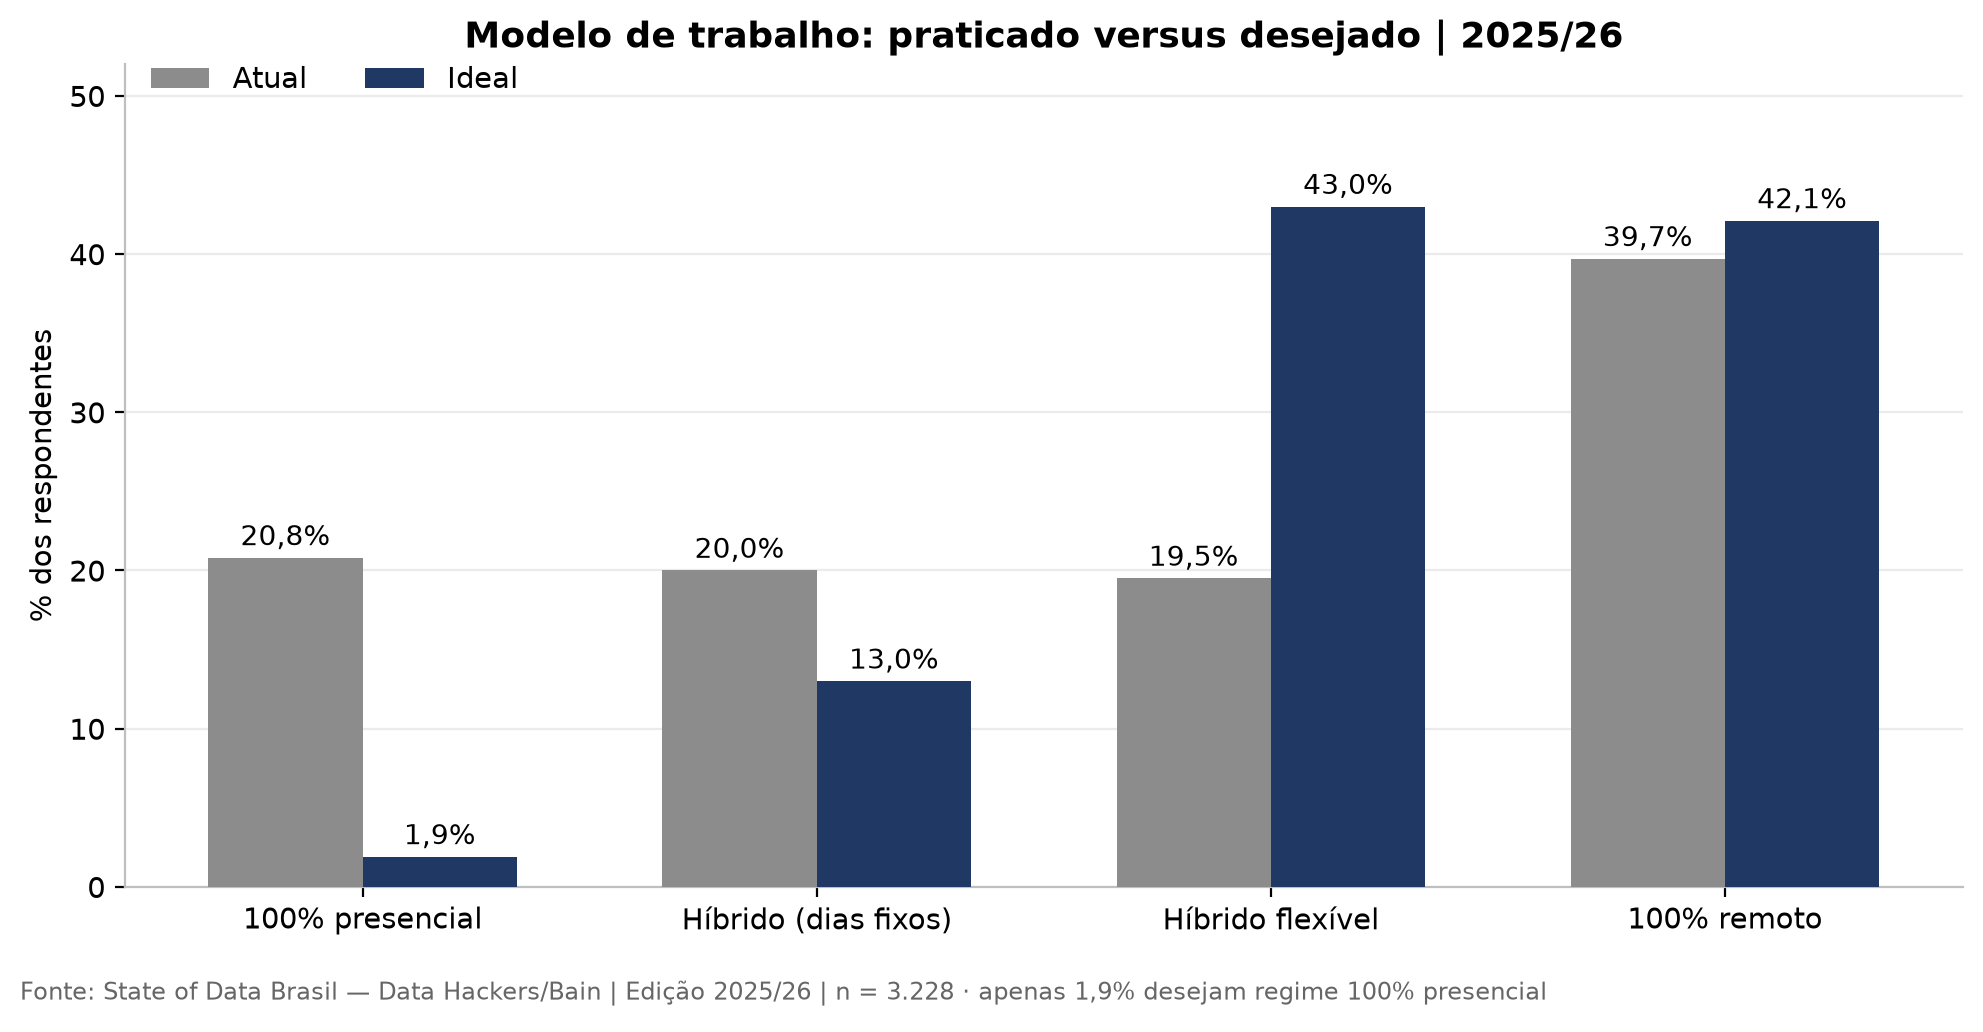

[grafico] G14_work_model


In [15]:
# G14 — Modelo de trabalho: praticado versus desejado (2025/26) -------------
d = ler("gold_work_model"); d25 = d[(d.ano == 2025) & (d.modelo != "Outro")]
ordem = ["100% presencial", "Híbrido (dias fixos)", "Híbrido flexível", "100% remoto"]
x = range(len(ordem)); larg = 0.34

fig, ax = nova_fig()
for i, (tipo, cor) in enumerate([("Atual", CINZA), ("Ideal", AZUL)]):
    da = d25[d25.tipo == tipo].set_index("modelo").reindex(ordem)
    pos = [p + (i - 0.5) * larg for p in x]
    ax.bar(pos, da.pct, width=larg, label=tipo, color=cor, zorder=3)
    for px, v in zip(pos, da.pct):
        if pd.notna(v):
            ax.text(px, v + 0.8, pct(v), ha="center", fontsize=10)
presencial = float(d25[(d25.tipo == "Ideal") & (d25.modelo == "100% presencial")].pct.iloc[0])
ax.set_xticks(list(x)); ax.set_xticklabels(ordem)
ax.set_title("Modelo de trabalho: praticado versus desejado | 2025/26")
ax.set_ylabel("% dos respondentes")
ax.set_ylim(0, 52)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(0.0, 1.03))
eixo(ax)
salvar(fig, "G14_work_model", [2025], d25[d25.tipo == "Atual"].n.sum(),
       f"apenas {pct(presencial)} desejam regime 100% presencial")

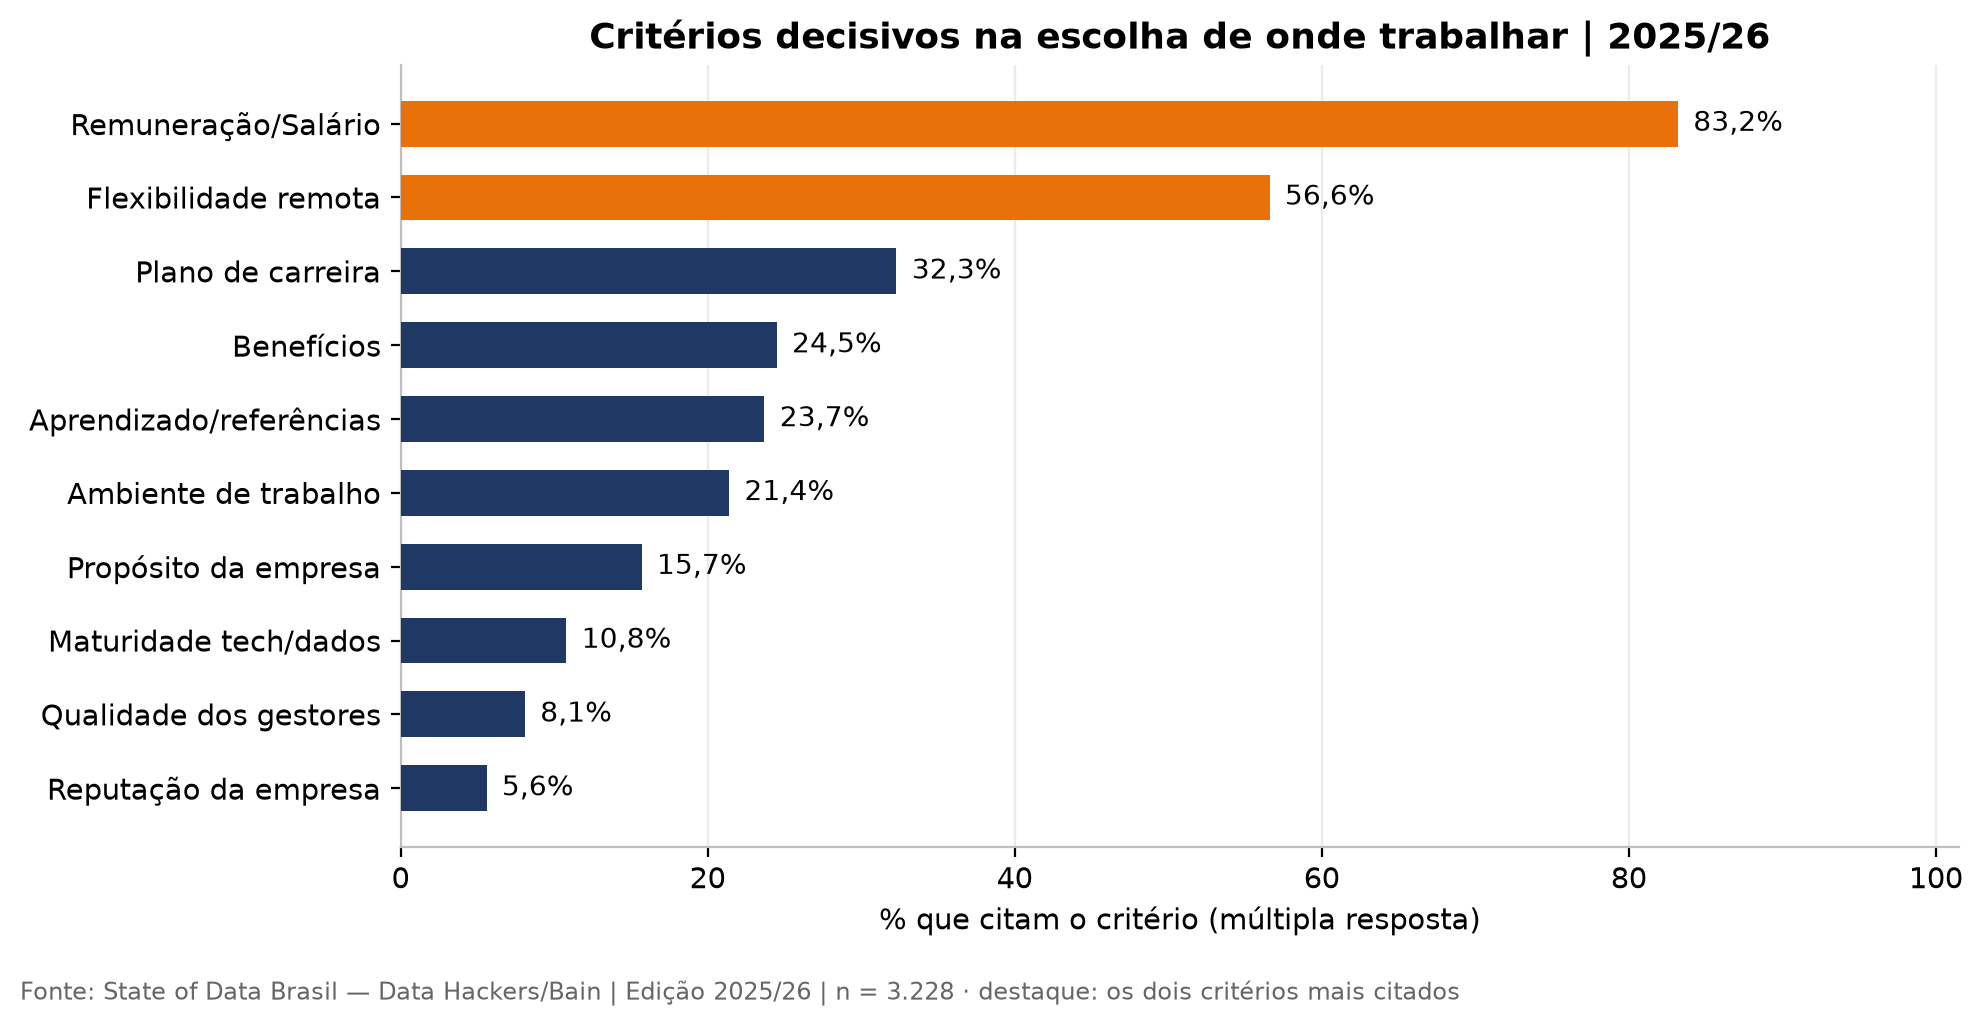

[grafico] G15_job_criteria

OK — 15 gráficos gerados em ../../consumption/charts


In [16]:
# G15 — Critérios decisivos na escolha de onde trabalhar (2025/26) ----------
d = ler("gold_job_criteria"); d25 = d[d.ano == 2025].sort_values("pct")
# destaque (laranja) nos dois critérios mais citados; demais em azul institucional
cores = [LARANJA if v in d25.pct.nlargest(2).values else AZUL for v in d25.pct]

fig, ax = nova_fig()
ax.barh(d25.criterio, d25.pct, color=cores, height=0.62, zorder=3)
for y, v in enumerate(d25.pct):
    ax.text(v + 1.0, y, pct(v), va="center", fontsize=10)
ax.set_title("Critérios decisivos na escolha de onde trabalhar | 2025/26")
ax.set_xlabel("% que citam o critério (múltipla resposta)")
ax.set_xlim(0, d25.pct.max() * 1.22)
eixo(ax, valor="x")
salvar(fig, "G15_job_criteria", [2025], d25.base_valida.max(), "destaque: os dois critérios mais citados")

print(f"\nOK — {len([f for f in os.listdir(OUT) if f.endswith('.png')])} gráficos gerados em {OUT}")

## Sincronização com o relatório técnico (PDF)
Mapeamento gráfico → figura do relatório: **G01→Figura 2, G02→Figura 3, G03→Figura 4, G04→Figura 5, G05→Figura 6, G06→Figura 7, G07→Figura 8, G08→Figura 9, G09→Figura 10, G10→Figura 11, G11→Figura 12, G12→Figura 13, G13→Figura 14, G14→Figura 15, G15→Figura 16** (a Figura 1 é o diagrama de arquitetura, gerado à parte). A célula abaixo reproduz, a partir da camada Gold, todos os indicadores de variação citados no relatório (pontos percentuais e crescimento relativo).


In [17]:
# Indicadores estatísticos citados no relatório — reprodutibilidade dos deltas (p.p. e ×)
br = lambda x: f"{x:+.1f}".replace(".", ",")                 # formatação PT-BR com sinal
def pcty(df, col, val, ano, campo="pct"):
    return float(df[(df[col] == val) & (df.ano == ano)][campo].iloc[0])

gen  = ler("gold_gender_participation")
tec  = ler("gold_technologies")
ia   = ler("gold_ai_priority")
gu   = ler("gold_genai_usage")
gs   = ler("gold_gender_seniority_salary"); g25 = gs[gs.ano == 2025]

fem22, fem25 = pcty(gen, "genero", "Feminino", 2022), pcty(gen, "genero", "Feminino", 2025)
py19,  py25  = pcty(tec, "tecnologia", "Python", 2019), pcty(tec, "tecnologia", "Python", 2025)
top2 = lambda a: float(ia[(ia.ano == a) & (ia.prioridade_ia_h.str.startswith(("1.", "2.")))].pct.sum())
nao23, nao25 = pcty(gu, "modalidade", "Não usa GenAI", 2023), pcty(gu, "modalidade", "Não usa GenAI", 2025)
emp23, emp25 = pcty(gu, "modalidade", "Empresa paga", 2023), pcty(gu, "modalidade", "Empresa paga", 2025)
sen = lambda g: float(g25[(g25.nivel == "Sênior") & (g25.genero == g)].salario_mediano_pm.iloc[0])

print(f"Participação feminina : pico {fem22}% (2022) → {fem25}% (2025/26) | Δ {br(fem25-fem22)} p.p.")
print(f"Python                : {py19}% (2019) → {py25}% (2025/26) | Δ {br(py25-py19)} p.p. | {py25/py19:.1f}×")
print(f"IA prioridade top-2   : {top2(2023):.1f}% → {top2(2025):.1f}% | Δ {br(top2(2025)-top2(2023))} p.p. | {top2(2025)/top2(2023):.1f}×")
print(f"GenAI 'não usa'       : {nao23}% → {nao25}% | Δ {br(nao25-nao23)} p.p.")
print(f"GenAI 'empresa paga'  : {emp23}% → {emp25}% | Δ {br(emp25-emp23)} p.p. | {emp25/emp23:.1f}×")
gapa = sen("Masculino") - sen("Feminino")
gapr = (1 - sen("Feminino")/sen("Masculino")) * 100
print(f"Gap Sênior            : R$ {mil(sen('Masculino'))} (M) vs R$ {mil(sen('Feminino'))} (F) | "
      f"R$ {mil(gapa)} absoluto | {gapr:.1f}% relativo")

Participação feminina : pico 24.8% (2022) → 22.0% (2025/26) | Δ -2,8 p.p.
Python                : 44.4% (2019) → 92.0% (2025/26) | Δ +47,6 p.p. | 2.1×
IA prioridade top-2   : 36.2% → 60.6% | Δ +24,4 p.p. | 1.7×
GenAI 'não usa'       : 19.7% → 2.1% | Δ -17,6 p.p.
GenAI 'empresa paga'  : 6.4% → 42.4% | Δ +36,0 p.p. | 6.6×
Gap Sênior            : R$ 14.001 (M) vs R$ 10.001 (F) | R$ 4.000 absoluto | 28.6% relativo
